In [1]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [2]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [3]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog

In [4]:
#Import data
from load_data import load_data

indep_vars, dep_vars = load_data(
    data_path='../AirFogSim/output/global_data.csv', 
    context_path='../AirFogSim/output/context_summary.json'
)

In [ ]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 3 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
"""

In [5]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehicle counts.
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot
Note: Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacity per node (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions. It shows complex oscillating behavior over time. Please consider:
- Polynomial terms (e.g., x1², x2³)
- Logarithmic or exponential structures
- Residual combinations or moving average style components

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs. It must be in the range [0, 1]. You are encouraged to use structures that naturally output bounded values, such as:
- Sigmoid: y = 1 / (1 + exp(-(…)))
- Bounded min/max: y = min(1, max(0, …))
"""

Running experiment 1...


d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:26: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  self.llm = ChatOpenAI(temperature=temp, model=model)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:36: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.equation_generation_chain = LLMChain(llm=self.llm, prompt=self.startup_promt)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:58: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will b

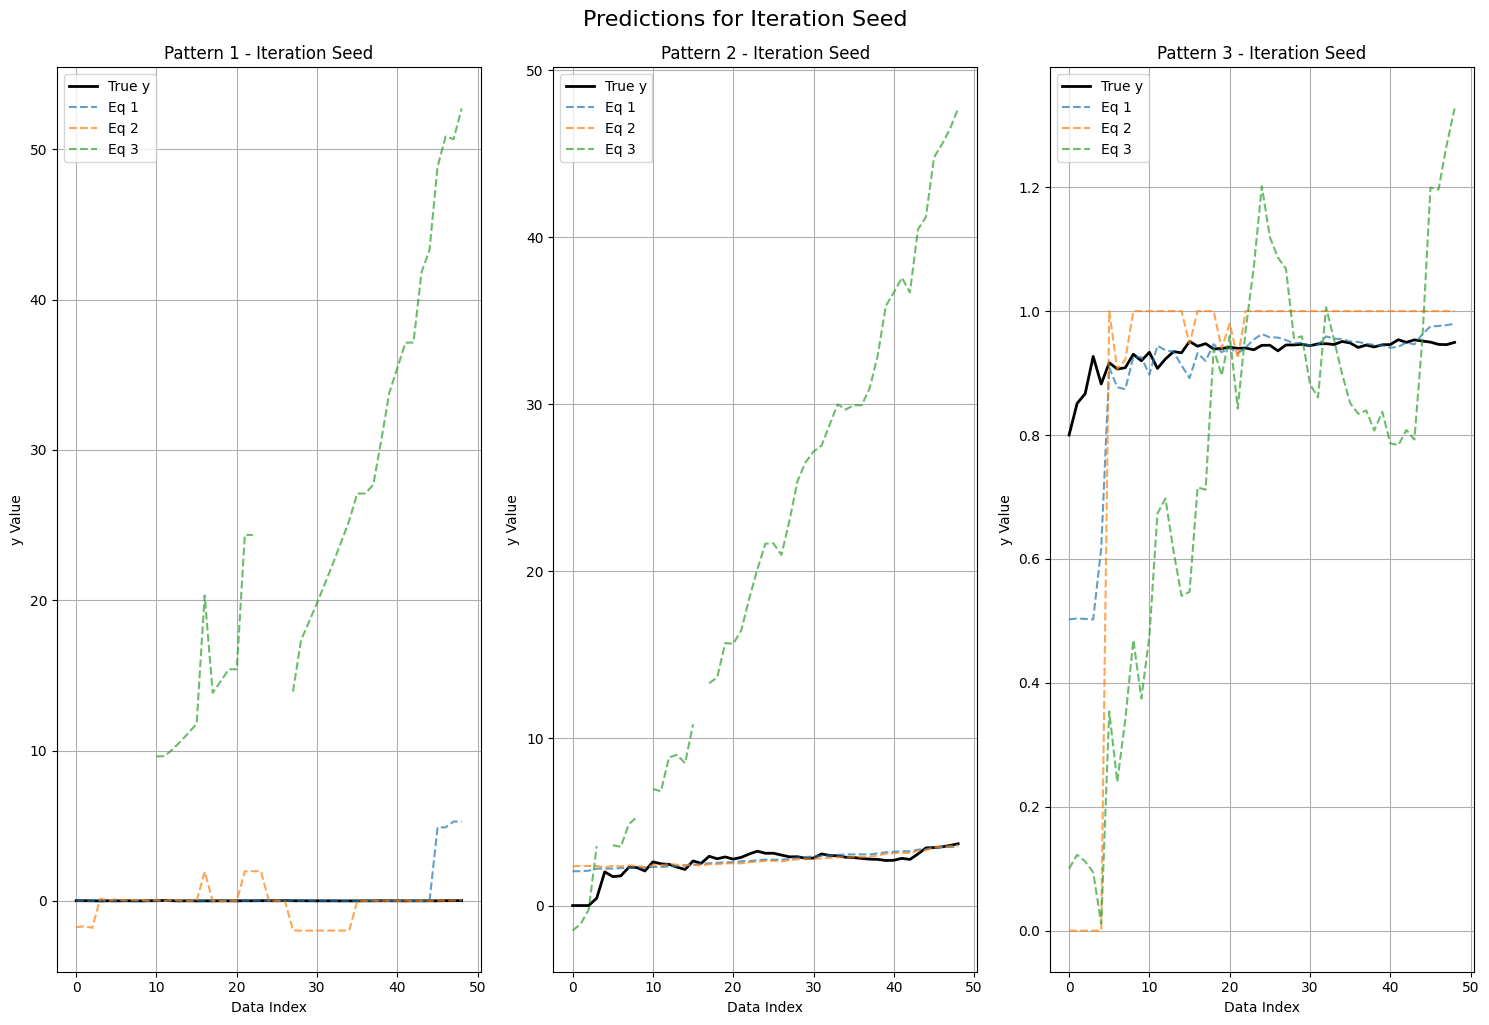

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:

Pattern 1:
- The average compute load is influenced by a combination of the task success ratio, vehicle density, UAV density, and junction vehicle counts. 
- Polynomial terms (e.g., x1², x2³) and logarithmic structures can capture the non-linear oscillating behavior.
- Consider interactions between variables for higher-order terms.

Pattern 2:
- The V2U rate depends on vehicle density, UAV density, and compute load. 
- Polynomial interactions such as x1*x2 and logarithmic terms can help capture spatial constraints.
- Exponential terms may describe the influence of compute load saturation.

Pattern 3:
- Task success ratio is bounded between [0,1] and depends on V2U rate, V2I rate, and compute load.
- Sigmoid structures are suitable for bounding.
- Polynomial interactions and logarithmic terms can describe resource constraints.
New equations generated:
- Equation 1: ['c[0]*x1+c[1]*x2**2+log(x3)*x4', '

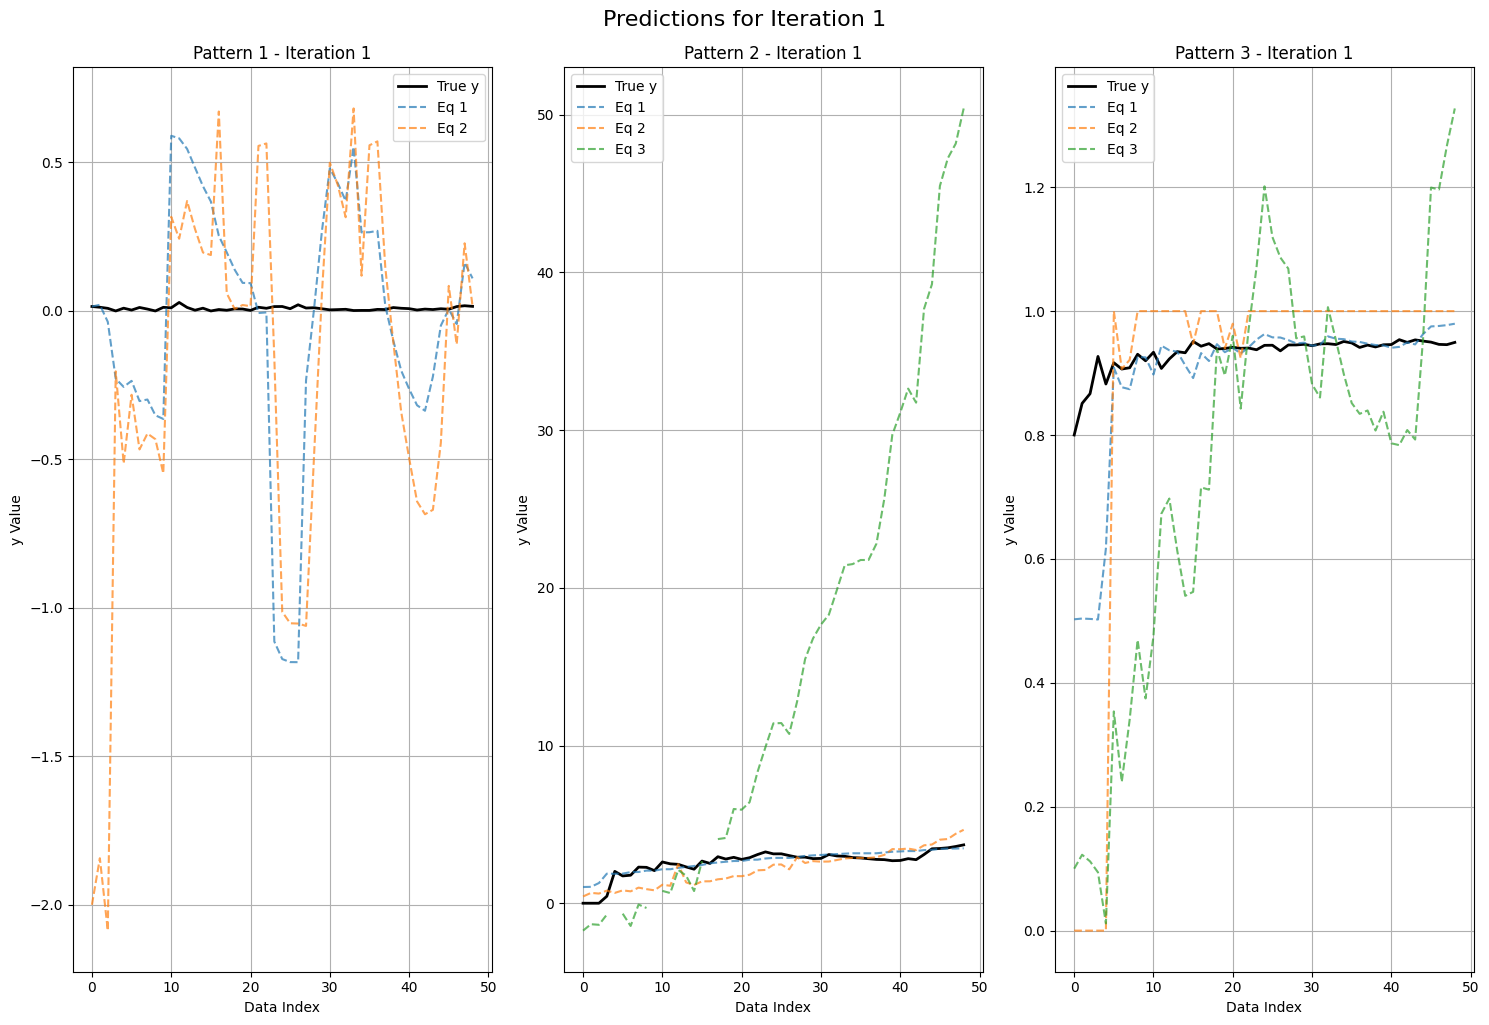

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1+c[1]*x2**2+log(x3)*x4', 'complexity': 14, 'nmae': np.float64(21.1328061771303), 'fitted_params': [-2.105322466054199, 0.0008342502034095089]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+log(x3)*sqrt(x4+x5+x6)', 'complexity': 21, 'nmae': np.float64(17.329751997299763), 'fitted_params': [-2.8777441646791537, -0.009803783209767512]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+sqrt(x5)*x6', 'complexity': 16, 'nmae': np.float64(14.608698655374083), 'fitted_params': [0.012230347857829366, -5.023164409830323e-05]}, {'equation': 'c[0]*x1*x2+c[1]*log(x3+x4)+sqrt(x5)', 'complexity': 15, 'nmae': np.float64(11.05391511928182), 'fitted_params': [-0.39744617689850803, 0.08005054495685326]}], [{'equation': 'c[0]*x1*x2+log(x3)', 'complexity': 8, 'nmae': np.float64(inf), 'fitted_params': [1.0]}, {'equation': 'c[0]*x1*x2+c[1]*x3**2', 'complexity': 11, 'nmae': np.float64(0.19548984111231119), 'fitted_params': [0.07905054210192974, 1823.1667109

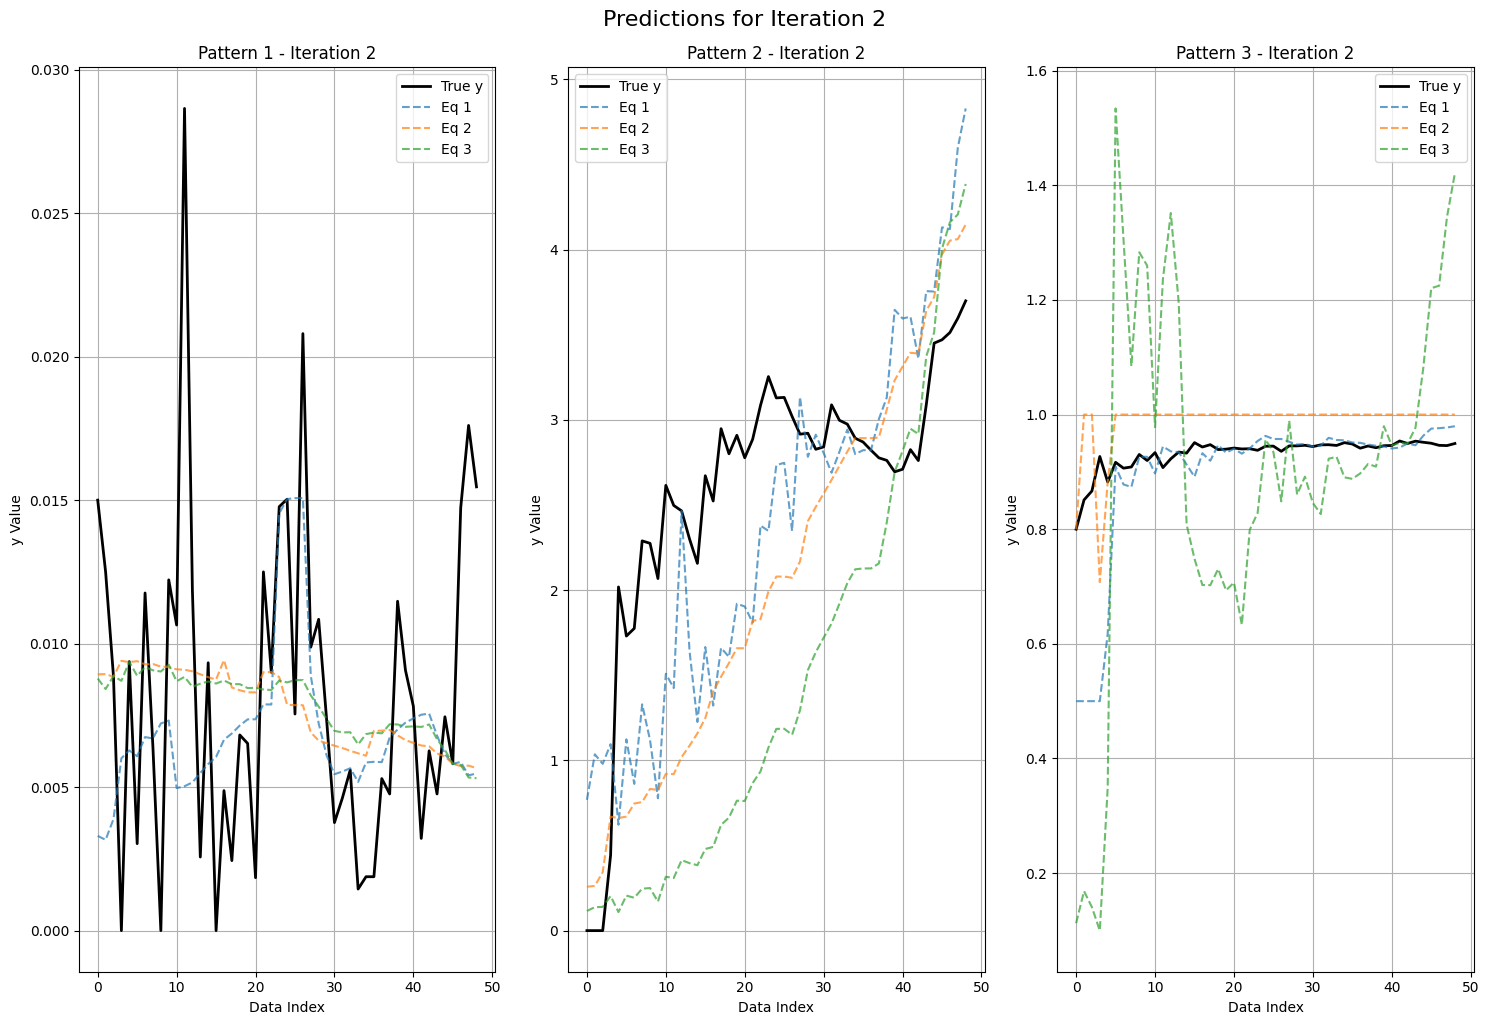

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**2+c[1]*x2**3+log(x3)*sqrt(x4+x5+x6)', 'complexity': 21, 'nmae': np.float64(17.329751997299763), 'fitted_params': [-2.8777441646791537, -0.009803783209767512]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+sqrt(x5)*x6', 'complexity': 16, 'nmae': np.float64(14.608698655374083), 'fitted_params': [0.012230347857829366, -5.023164409830323e-05]}, {'equation': 'c[0]*x1*x2+c[1]*log(x3+x4)+sqrt(x5)', 'complexity': 15, 'nmae': np.float64(11.05391511928182), 'fitted_params': [-0.39744617689850803, 0.08005054495685326]}, {'equation': 'c[0]*x1*x2+c[1]*sqrt(x3)+c[2]*x4', 'complexity': 14, 'nmae': np.float64(0.1489546320459913), 'fitted_params': [-0.0006436237602778698, 0.003415279863280178, 0.0008822049535654355]}, {'equation': 'c[0]*x1**2+c[1]*x2/(x5+1)', 'complexity': 13, 'nmae': np.float64(0.14655310999798712), 'fitted_params': [0.002540166942046185, 0.0035596062139376947]}], [{'equation': 'c[0]*x1*x2+log(x3)', 'complexity': 8, '

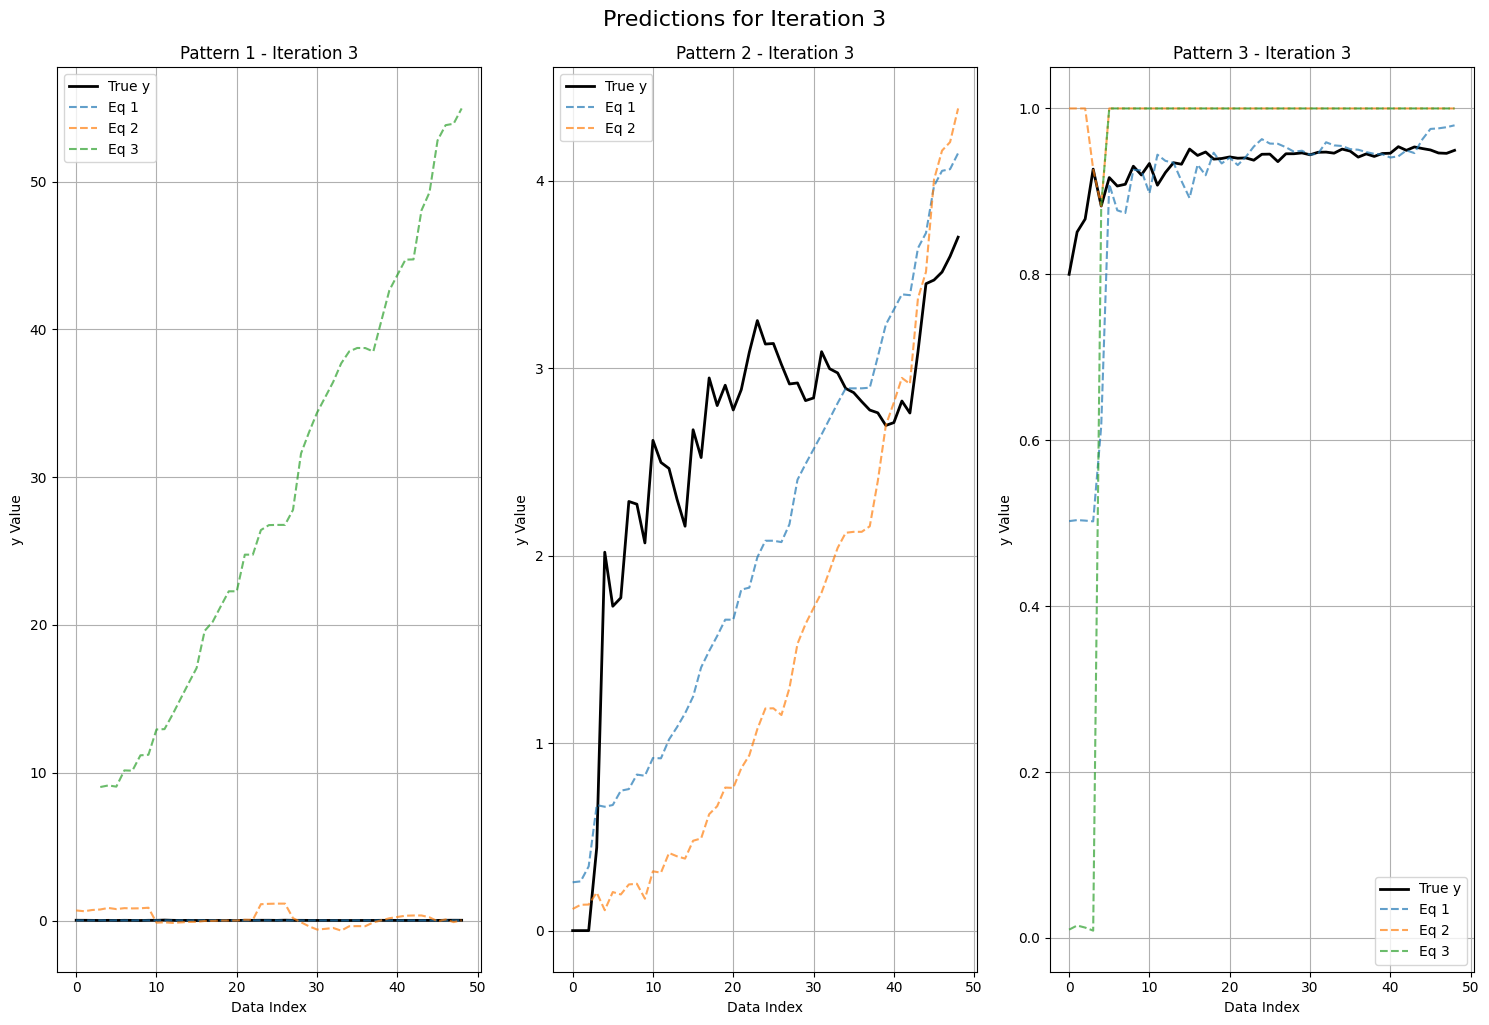

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**2+c[1]*x2**3+log(x3)*sqrt(x4+x5+x6)', 'complexity': 21, 'nmae': np.float64(17.329751997299763), 'fitted_params': [-2.8777441646791537, -0.009803783209767512]}, {'equation': 'c[0]*x1**2+c[1]*x2**3-sqrt(x5+x6)', 'complexity': 16, 'nmae': np.float64(13.71614449482829), 'fitted_params': [0.9796054009579283, 0.005745767290297391]}, {'equation': 'c[0]*x1*x2+c[1]*log(x3+x4)+sqrt(x5)', 'complexity': 15, 'nmae': np.float64(11.05391511928182), 'fitted_params': [-0.39744617689850803, 0.08005054495685326]}, {'equation': 'c[0]*x1*x2+c[1]*sqrt(x3)+c[2]*x4/(x5+1)', 'complexity': 18, 'nmae': np.float64(0.1495418017517901), 'fitted_params': [-0.00039755656987191195, 0.0030563865200109257, 0.0016043866739917602]}, {'equation': 'c[0]*x1*x2+c[1]*sqrt(x3)+c[2]*x4', 'complexity': 14, 'nmae': np.float64(0.1489546320459913), 'fitted_params': [-0.0006436237602778698, 0.003415279863280178, 0.0008822049535654355]}, {'equation': 'c[0]*x1

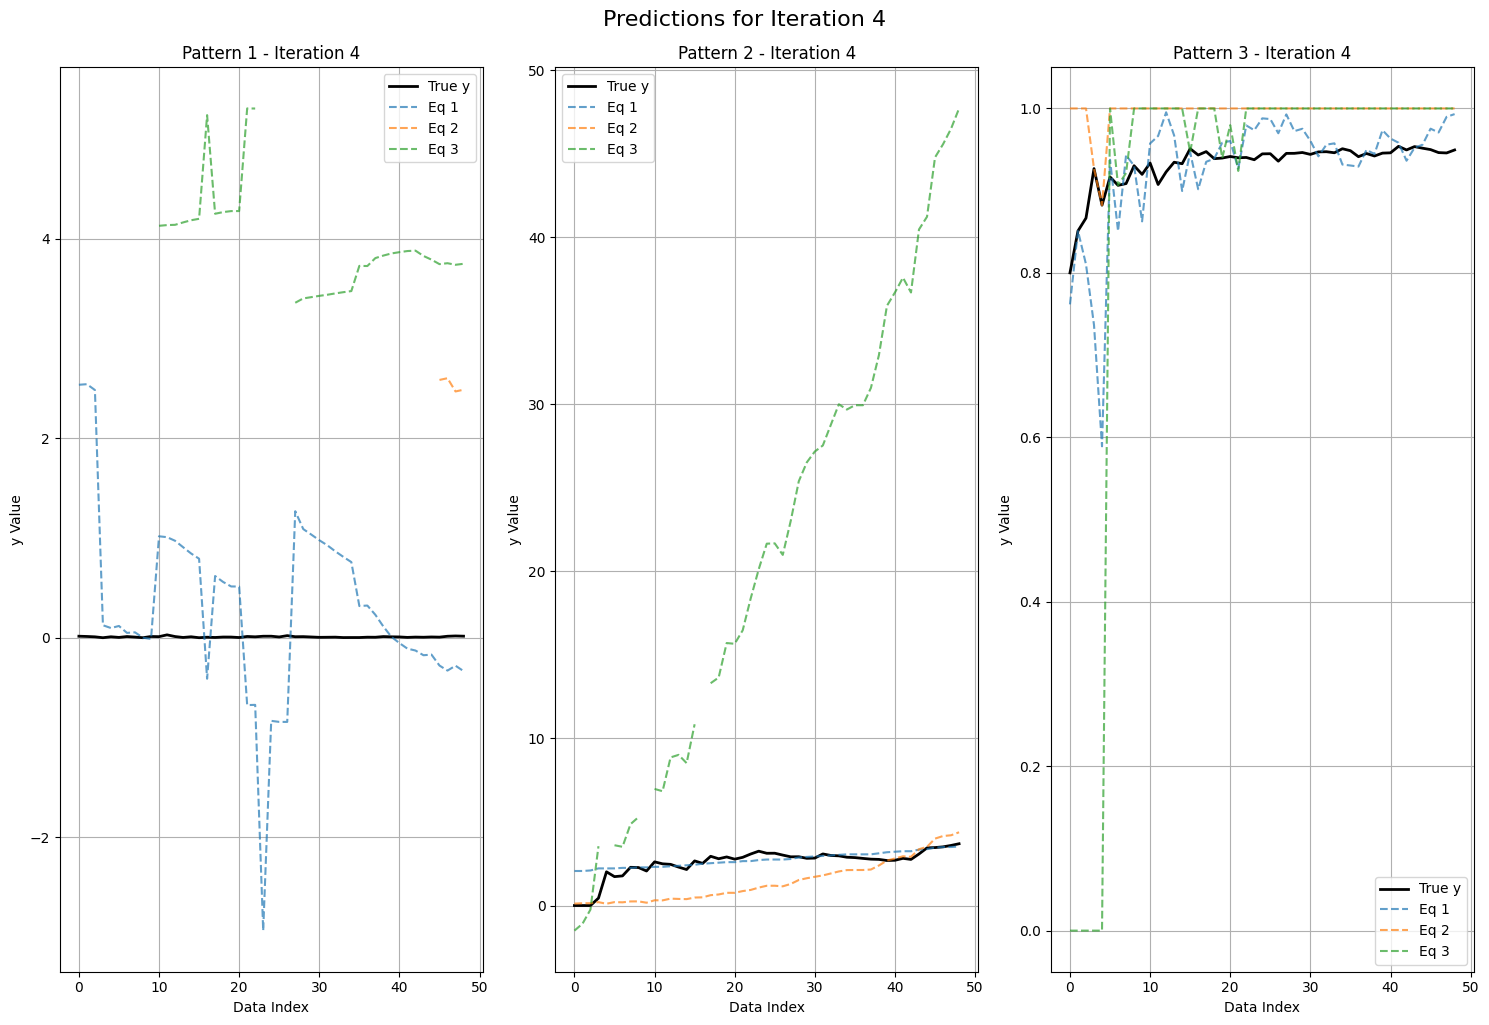

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**2+c[1]*x2**3+log(x3)*sqrt(x4+x5+x6)', 'complexity': 21, 'nmae': np.float64(17.329751997299763), 'fitted_params': [-2.8777441646791537, -0.009803783209767512]}, {'equation': 'c[0]*x1**2+c[1]*x2**3-sqrt(x5+x6)', 'complexity': 16, 'nmae': np.float64(13.71614449482829), 'fitted_params': [0.9796054009579283, 0.005745767290297391]}, {'equation': 'c[0]*x1*x2+c[1]*log(x3+x4)+sqrt(x5)', 'complexity': 15, 'nmae': np.float64(11.05391511928182), 'fitted_params': [-0.39744617689850803, 0.08005054495685326]}, {'equation': 'c[0]*x1*x2+c[1]*sqrt(x3)+c[2]*x4/(x5+1)', 'complexity': 18, 'nmae': np.float64(0.1495418017517901), 'fitted_params': [-0.00039755656987191195, 0.0030563865200109257, 0.0016043866739917602]}, {'equation': 'c[0]*x1*x2+c[1]*sqrt(x3)+c[2]*x4', 'complexity': 14, 'nmae': np.float64(0.1489546320459913), 'fitted_params': [-0.0006436237602778698, 0.003415279863280178, 0.0008822049535654355]}, {'equation': 'c[0]*x1

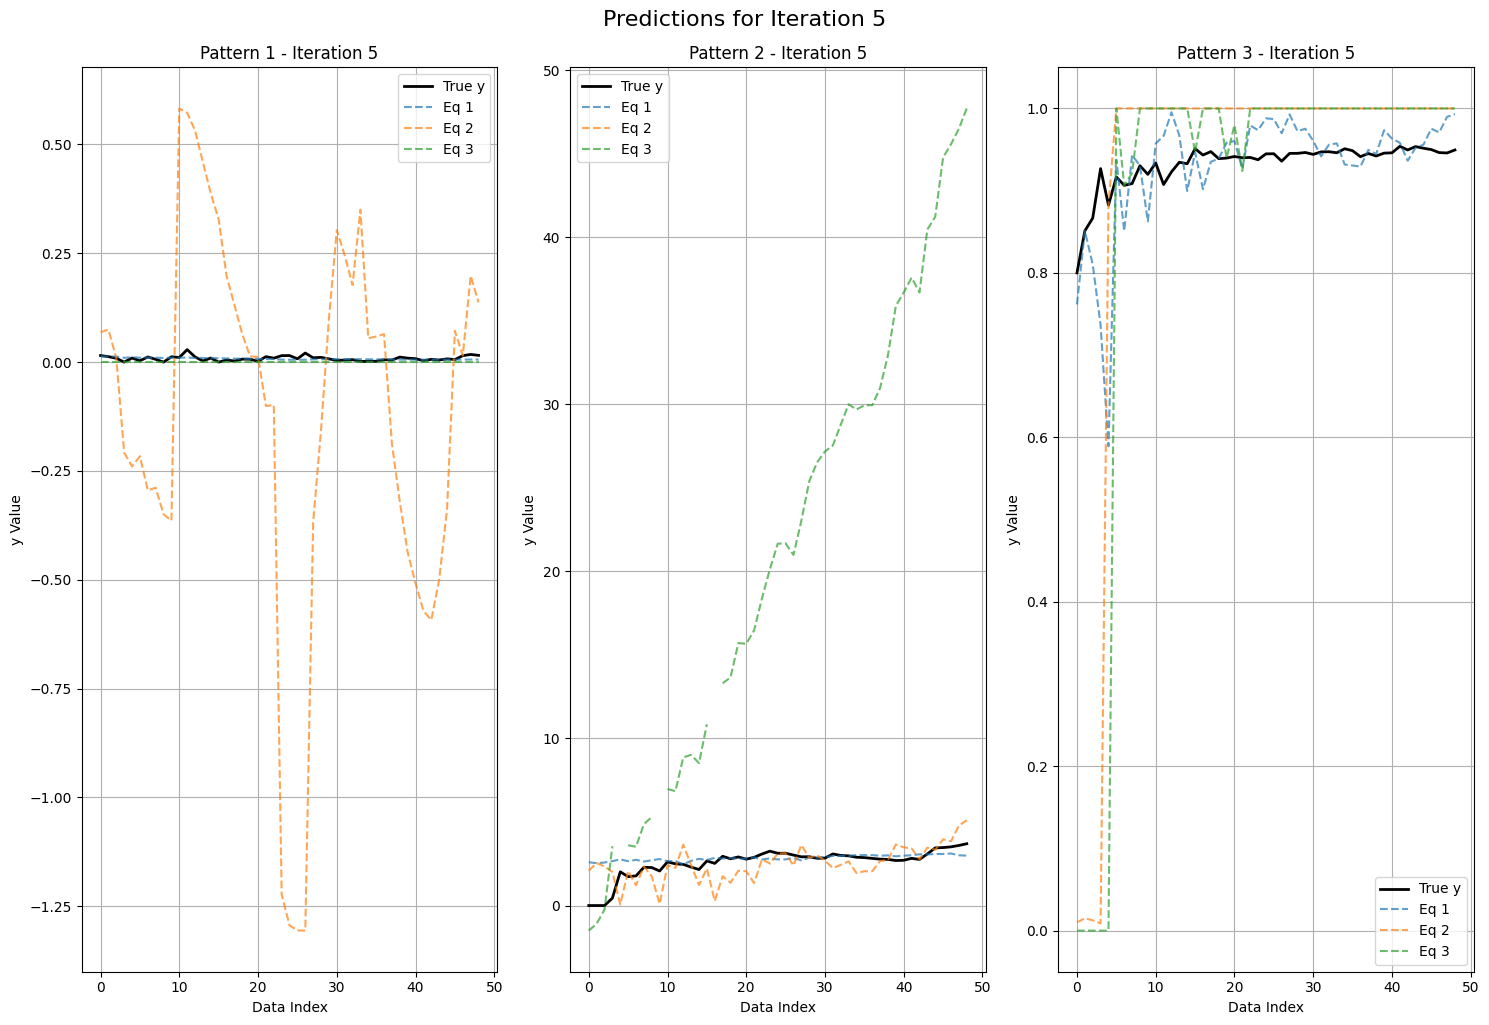

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*movavg(1, 3)*x2/(x5+x6)+log(x3)', 'complexity': 12, 'nmae': np.float64(inf), 'fitted_params': [1.0]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+log(x3)*sqrt(x4+x5+x6)', 'complexity': 21, 'nmae': np.float64(17.329751997299763), 'fitted_params': [-2.8777441646791537, -0.009803783209767512]}, {'equation': 'c[0]*x1**2+c[1]*x2**3-sqrt(x5+x6)', 'complexity': 16, 'nmae': np.float64(13.71614449482829), 'fitted_params': [0.9796054009579283, 0.005745767290297391]}, {'equation': 'c[0]*x1*x2+c[1]*log(x3+x4)+sqrt(x5+x6)', 'complexity': 17, 'nmae': np.float64(11.726689512673307), 'fitted_params': [-0.45719076670559755, 0.11796818202681808]}, {'equation': 'c[0]*x1*x2+c[1]*log(x3+x4)+sqrt(x5)', 'complexity': 15, 'nmae': np.float64(11.05391511928182), 'fitted_params': [-0.39744617689850803, 0.08005054495685326]}, {'equation': 'c[0]*x1*x2+c[1]*sqrt(x3)+c[2]*x4/(x5+1)', 'complexity': 18, 'nmae': np.float64(0.1495418017517901), 'fitted_par

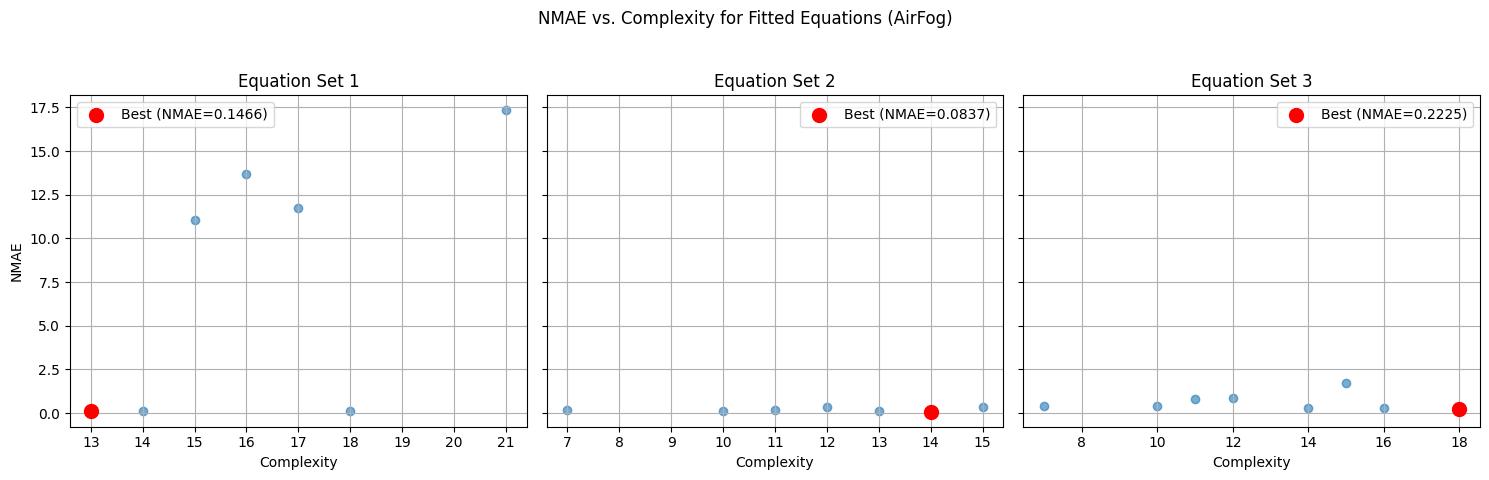

Experiment 1 finished.
Running experiment 2...


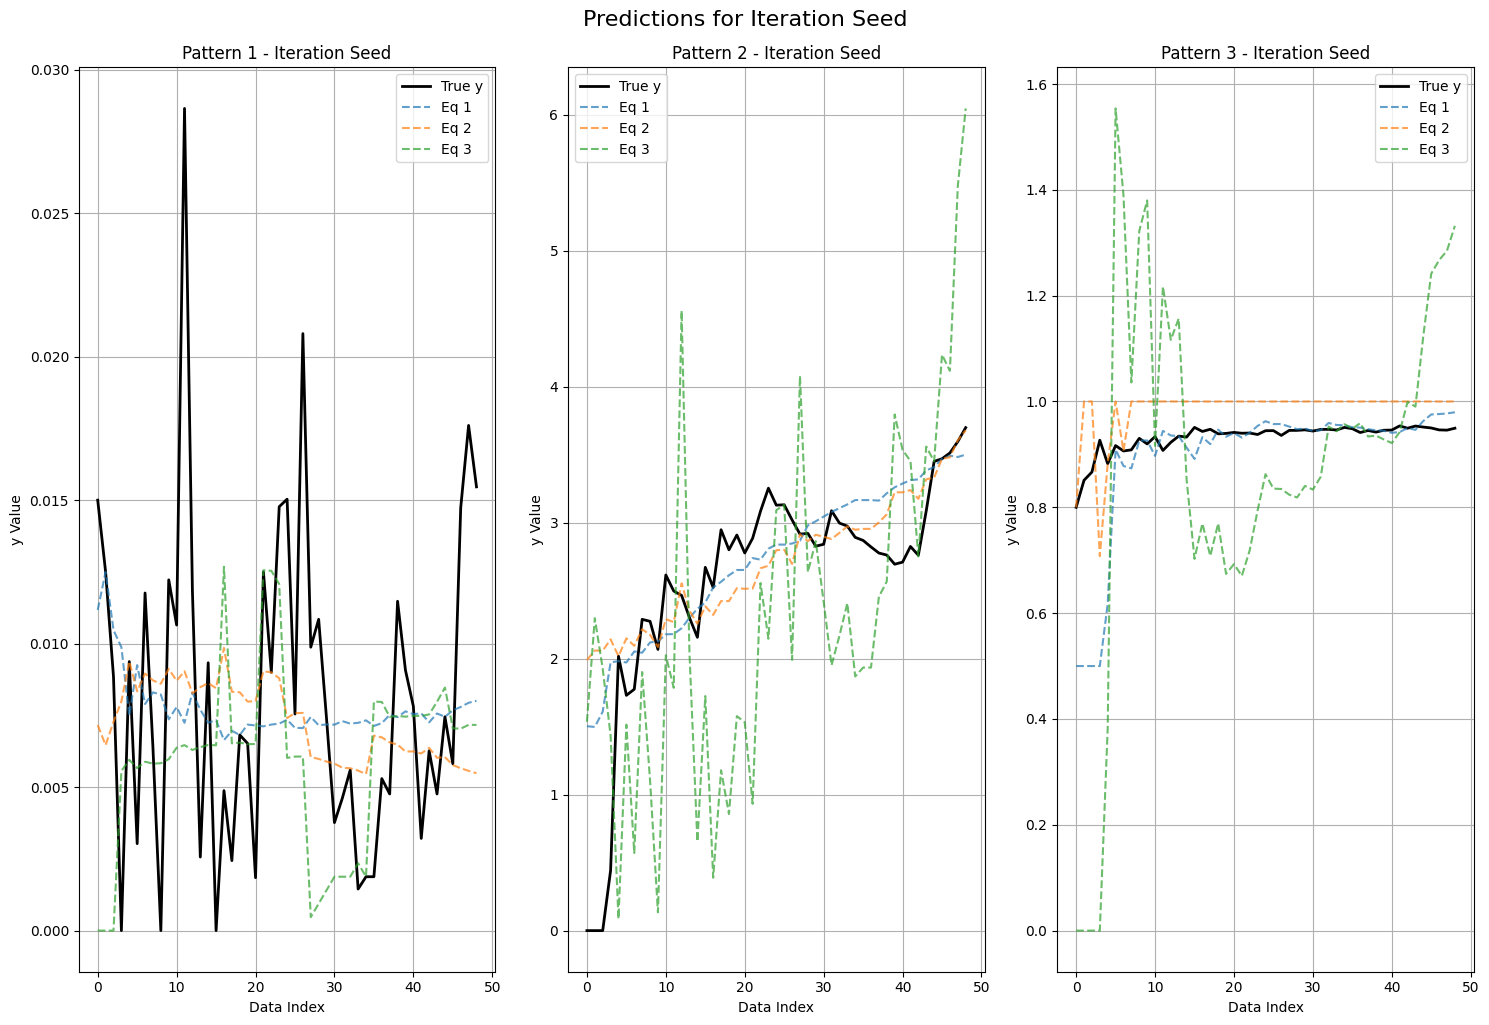

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:

Pattern 1 Analysis:
- The dependent variable "average compute load" shows oscillatory behavior influenced by task success ratio and density of vehicles/UAVs.
- Polynomial structures (e.g., squares or cubes) could model the influence of density variables.
- Logarithmic terms may capture diminishing returns in compute load as vehicle and UAV density increases.

Pattern 2 Analysis:
- The dependent variable "average V2U rate" depends on vehicle density, UAV density, and compute load.
- Linear, polynomial, or multiplicative terms of the independent variables may work well given the interplay between density and communication constraints.

Pattern 3 Analysis:
- The dependent variable "task success ratio" must remain bounded [0, 1], which suggests using sigmoid-like structures or bounded operations.
- Dependencies on V2U rate, V2I rate, and compute load can be expressed in ratios and exponential structures

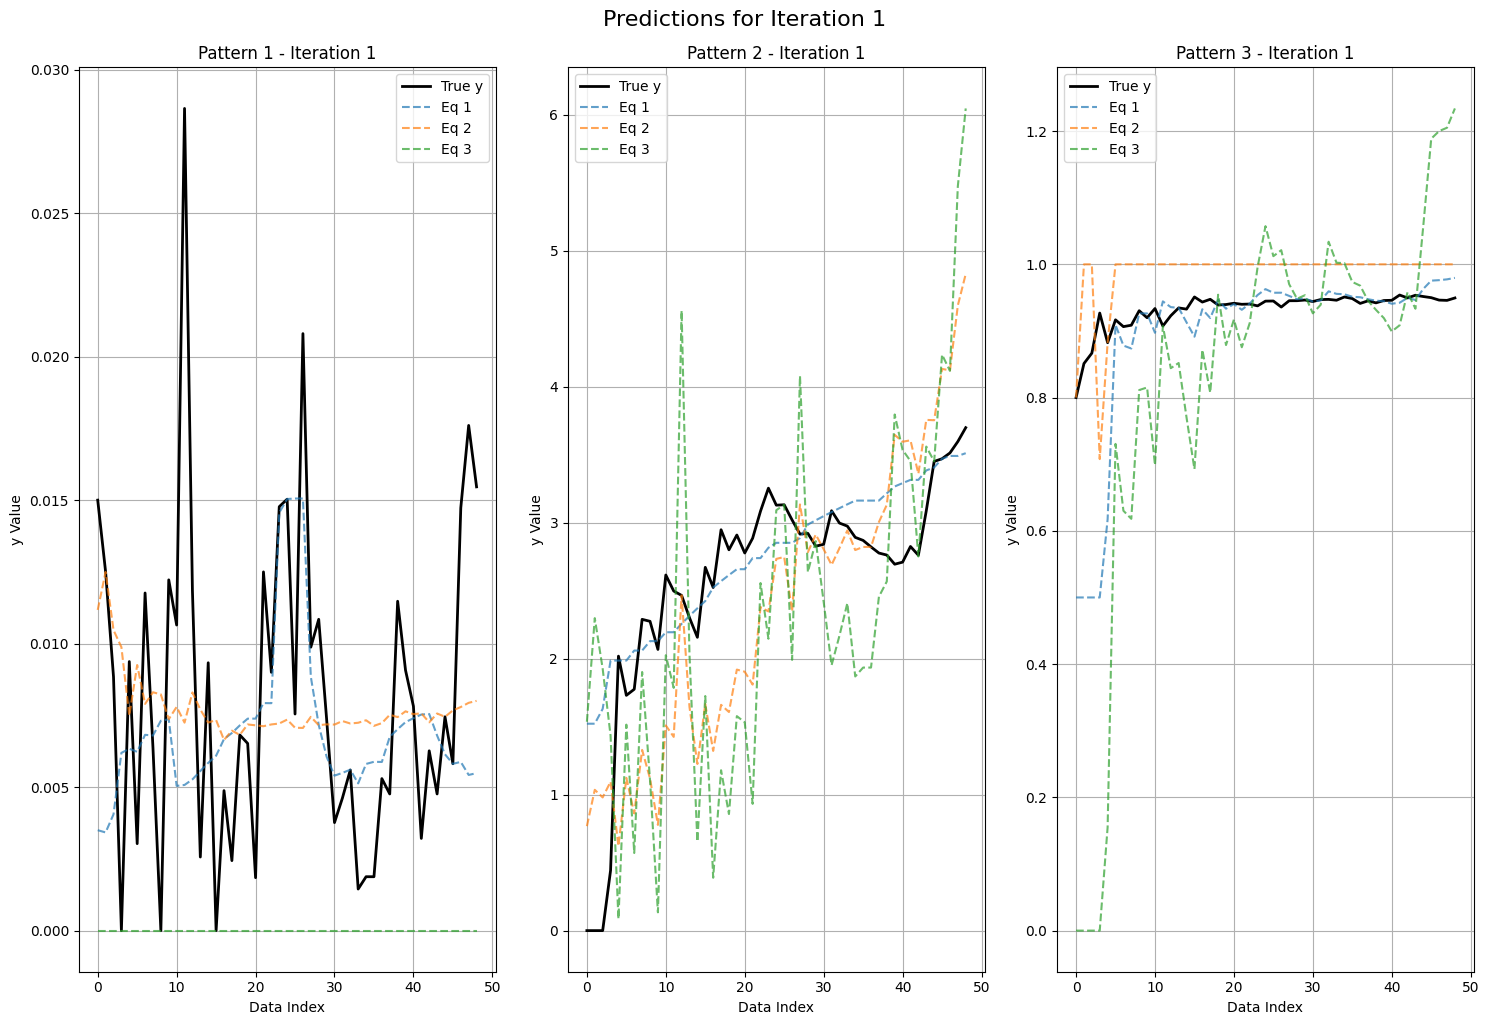

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1*x4+c[1]*x5/(x6+1)', 'complexity': 13, 'nmae': np.float64(0.177641204606914), 'fitted_params': [0.006419132047591392, 0.00046952102382741794]}, {'equation': 'c[0]*movavg(1, 3)+c[1]*x2*x4', 'complexity': 9, 'nmae': np.float64(0.15456010515982527), 'fitted_params': [0.006690800825141408, 0.00026035359850789294]}, {'equation': 'c[0]*x1+c[1]*x2/(x5+1)+c[2]*sqrt(x4)', 'complexity': 16, 'nmae': np.float64(0.14614042914343078), 'fitted_params': [0.002361459694990537, 0.003548030327873539, 6.329227168329923e-05]}], [{'equation': 'c[0]*x1**2+c[1]*x3/(x2+1)', 'complexity': 13, 'nmae': np.float64(0.27156321600950456), 'fitted_params': [0.06501257432351125, 1248.8172203909317]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.18559096685317308), 'fitted_params': [0.5404780345304192, 7.435605430874402]}, {'equation': 'c[0]*x1+c[1]*x2+c[2]*x3', 'complexity': 11, 'nmae': np.float64(0.09644292807234053)

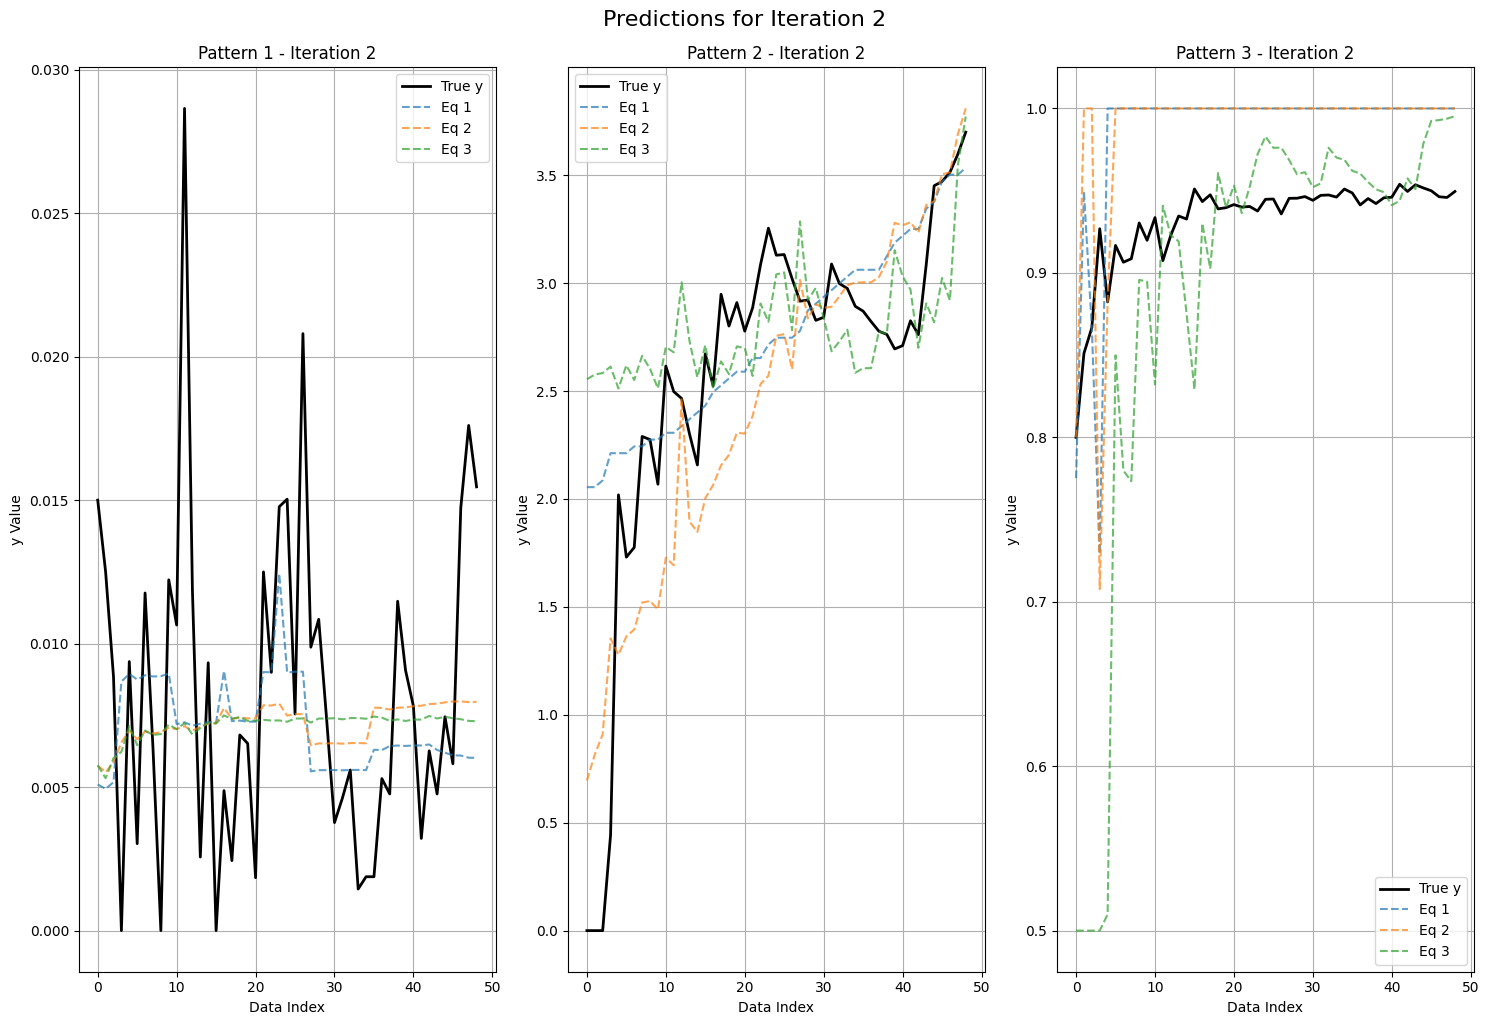

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1*x4+c[1]*x5/(x6+1)', 'complexity': 13, 'nmae': np.float64(0.177641204606914), 'fitted_params': [0.006419132047591392, 0.00046952102382741794]}, {'equation': 'c[0]*x1**2+c[1]*x2**3', 'complexity': 11, 'nmae': np.float64(0.15669237404231984), 'fitted_params': [0.008297271799595368, -3.46723814233934e-07]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2*x4)', 'complexity': 10, 'nmae': np.float64(0.15501971879325072), 'fitted_params': [0.006899341520044873, 0.0005395967757090566]}, {'equation': 'c[0]*movavg(1, 3)+c[1]*x2*x4', 'complexity': 9, 'nmae': np.float64(0.15456010515982527), 'fitted_params': [0.006690800825141408, 0.00026035359850789294]}, {'equation': 'c[0]*log(x1+1)+c[1]*x4/(x5+1)', 'complexity': 14, 'nmae': np.float64(0.15113127447712524), 'fitted_params': [0.008401070749072799, 0.0034344283862694372]}, {'equation': 'c[0]*x1+c[1]*x2/(x5+1)+c[2]*sqrt(x4)', 'complexity': 16, 'nmae': np.float64(0.14614042914343078), 'fi

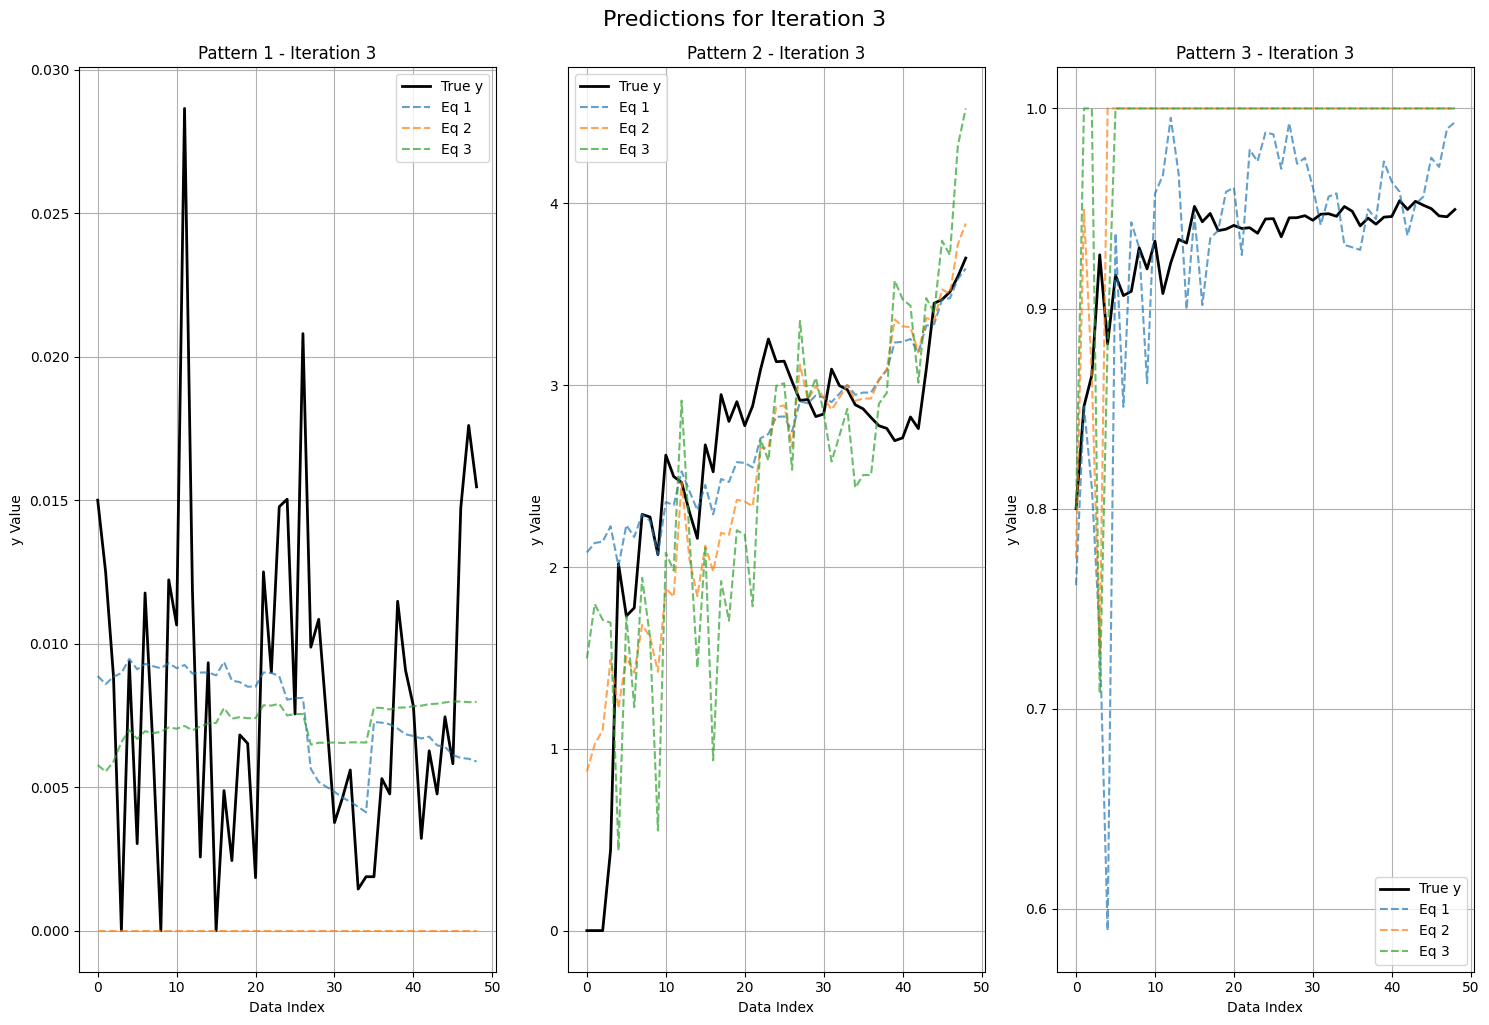

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1*x4+c[1]*x5/(x6+1)', 'complexity': 13, 'nmae': np.float64(0.177641204606914), 'fitted_params': [0.006419132047591392, 0.00046952102382741794]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2*x4)', 'complexity': 10, 'nmae': np.float64(0.15501970636265122), 'fitted_params': [0.006925356747866623, 0.0005293565914833267]}, {'equation': 'c[0]*movavg(1, 3)+c[1]*x2*x4', 'complexity': 9, 'nmae': np.float64(0.15456010515982527), 'fitted_params': [0.006690800825141408, 0.00026035359850789294]}, {'equation': 'c[0]*movavg(1, 3)+c[1]*x4/(x5+1)', 'complexity': 11, 'nmae': np.float64(0.15159395429647488), 'fitted_params': [0.005917791860899963, 0.003435389972615435]}, {'equation': 'c[0]*log(x1+1)+c[1]*x2/(x4+1)', 'complexity': 14, 'nmae': np.float64(0.14736443277461334), 'fitted_params': [0.0155155452079095, -0.001232518386320253]}, {'equation': 'c[0]*x1+c[1]*x2/(x5+1)+c[2]*sqrt(x4)', 'complexity': 16, 'nmae': np.float64(0.146140429143430

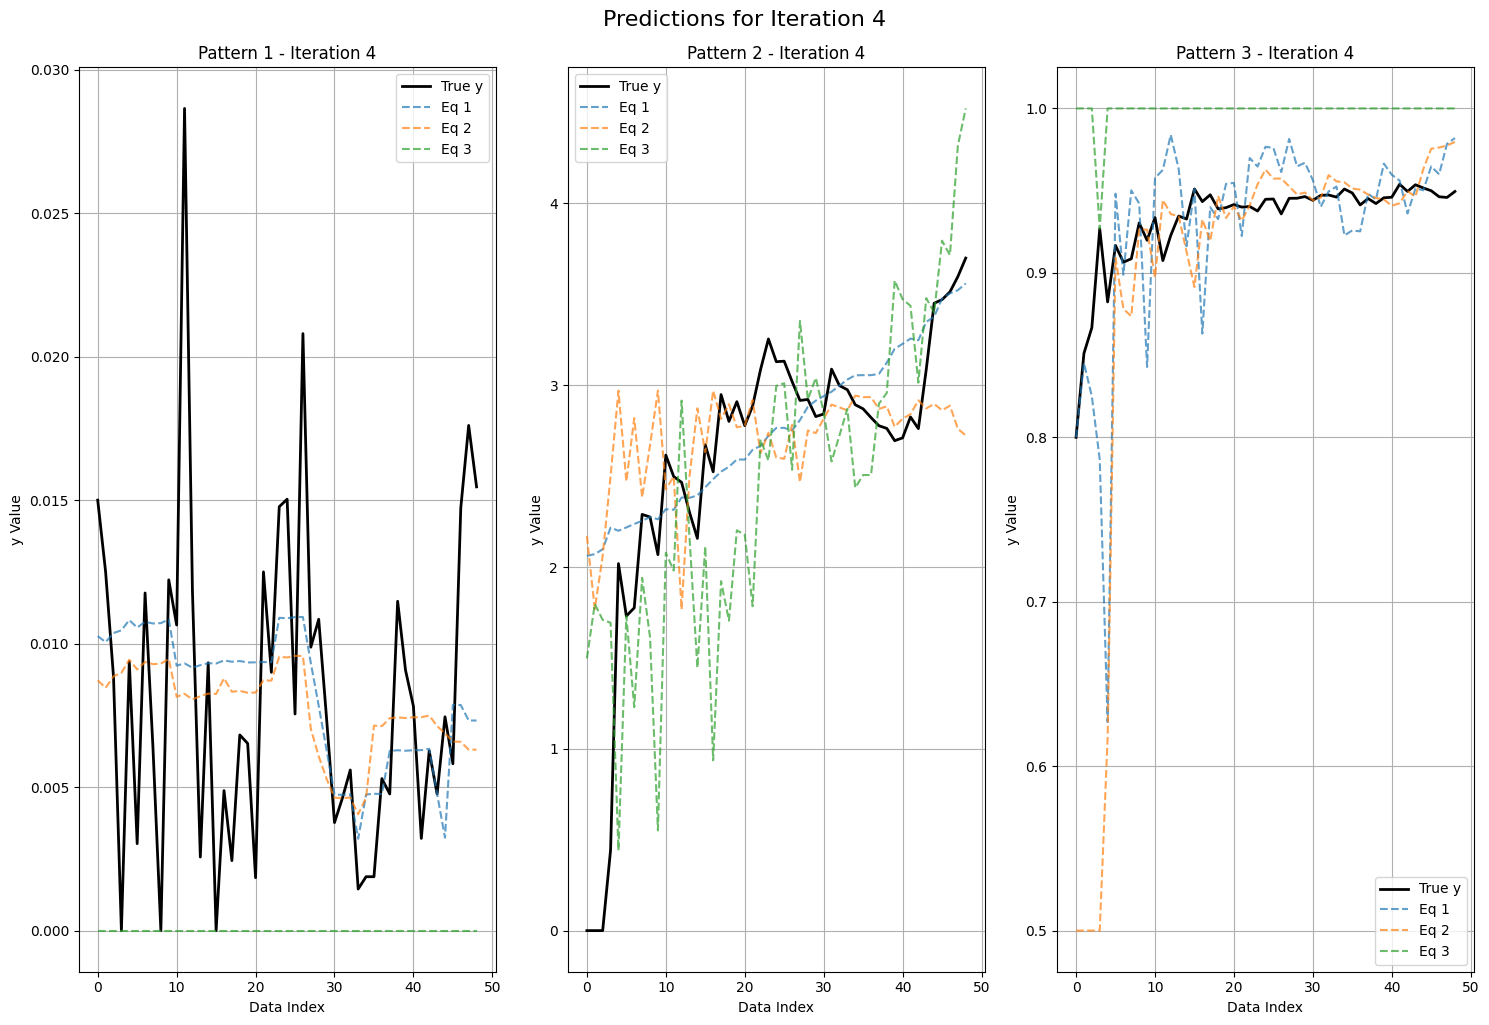

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1*x4+c[1]*x5/(x6+1)', 'complexity': 13, 'nmae': np.float64(0.177641204606914), 'fitted_params': [0.006419132047591392, 0.00046952102382741794]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2*x4)', 'complexity': 10, 'nmae': np.float64(0.15501970636265122), 'fitted_params': [0.006925356747866623, 0.0005293565914833267]}, {'equation': 'c[0]*movavg(1, 3)+c[1]*x2*x4', 'complexity': 9, 'nmae': np.float64(0.15456010515982527), 'fitted_params': [0.006690800825141408, 0.00026035359850789294]}, {'equation': 'c[0]*movavg(1, 3)+c[1]*x4/(x5+1)', 'complexity': 11, 'nmae': np.float64(0.15159395429647488), 'fitted_params': [0.005917791860899963, 0.003435389972615435]}, {'equation': 'c[0]*log(x1+1)+c[1]*x2/(x4+1)', 'complexity': 14, 'nmae': np.float64(0.14736443277461334), 'fitted_params': [0.0155155452079095, -0.001232518386320253]}, {'equation': 'c[0]*x1+c[1]*x2/(x5+1)+c[2]*sqrt(x4)', 'complexity': 16, 'nmae': np.float64(0.146140429143430

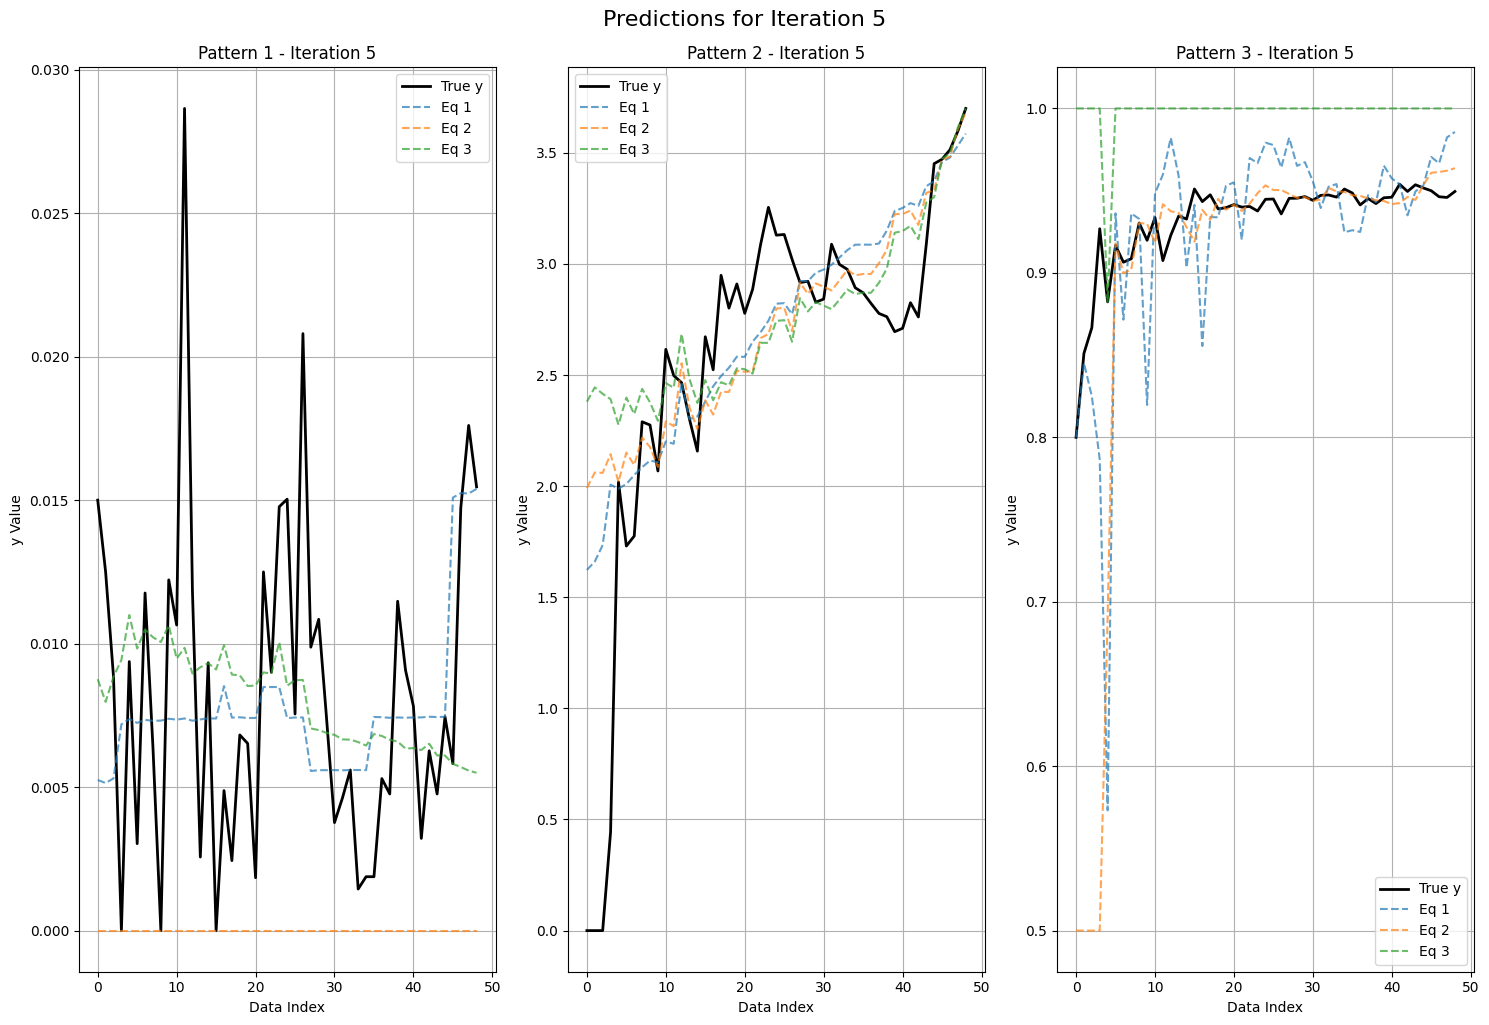

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1*x4+c[1]*x5/(x6+1)', 'complexity': 13, 'nmae': np.float64(0.177641204606914), 'fitted_params': [0.006419132047591392, 0.00046952102382741794]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2*x4)', 'complexity': 10, 'nmae': np.float64(0.15501970636265122), 'fitted_params': [0.006925356747866623, 0.0005293565914833267]}, {'equation': 'c[0]*movavg(1, 3)+c[1]*x2*x4', 'complexity': 9, 'nmae': np.float64(0.15456010515982527), 'fitted_params': [0.006690800825141408, 0.00026035359850789294]}, {'equation': 'c[0]*movavg(1, 3)+c[1]*x4/(x5+1)', 'complexity': 11, 'nmae': np.float64(0.15159395429647488), 'fitted_params': [0.005917791860899963, 0.003435389972615435]}, {'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x4/(x5+1)', 'complexity': 20, 'nmae': np.float64(0.15087818051664628), 'fitted_params': [0.01448858462819675, -0.003627045732647909, 0.0013286147127097151]}, {'equation': 'c[0]*log(x1+1)+c[1]*x2/(x4+1)', 'complexity': 14, 'nmae': 

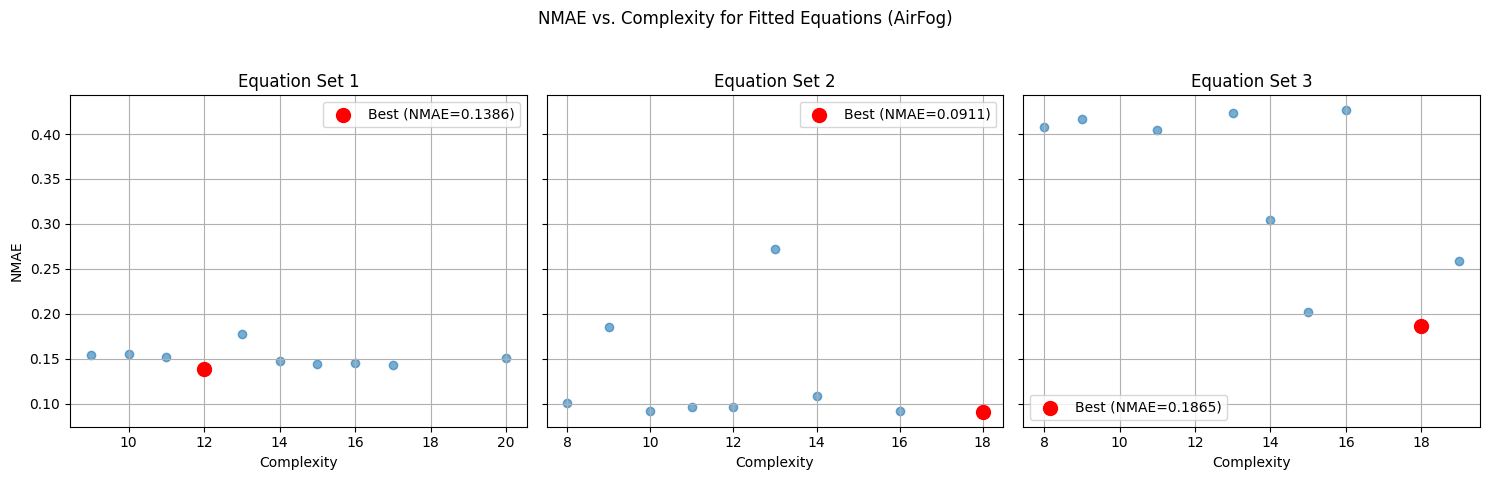

Experiment 2 finished.
Running experiment 3...


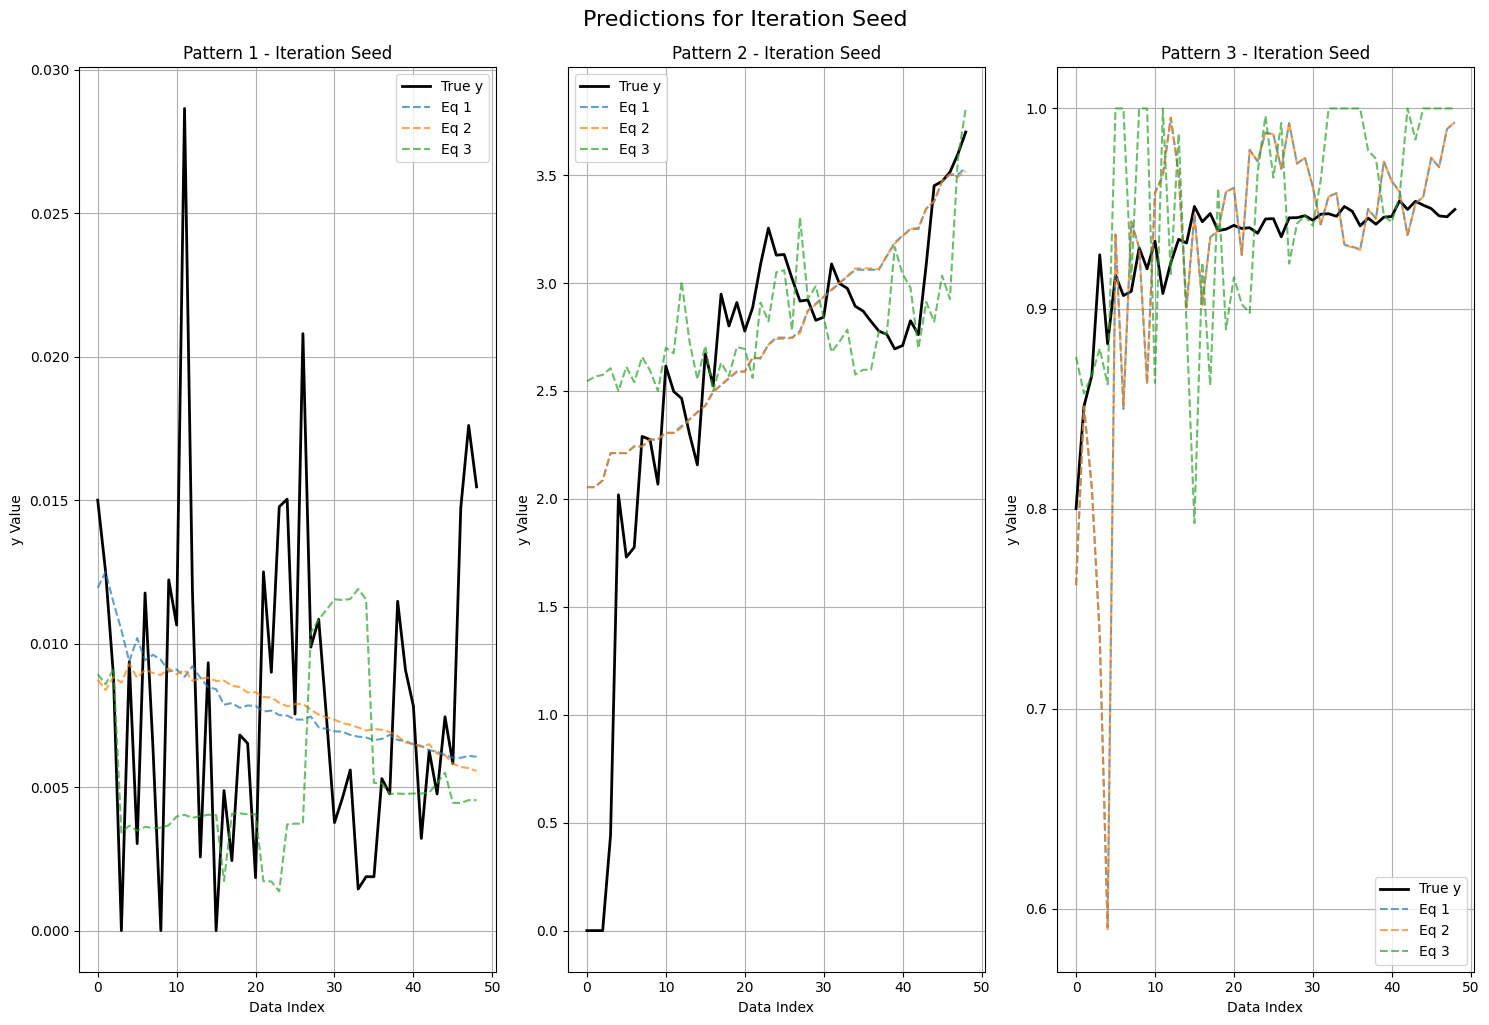

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:
- For Pattern 1, the dependent variable (average compute load) may correlate with polynomial terms of success ratio, vehicle density, and UAV density due to oscillatory behavior. Incorporating logarithmic or exponential terms can capture non-linear trends. Junction vehicle counts might act as modifiers.
- For Pattern 2, the dependent variable (average V2U rate) likely scales with vehicle density and UAV density. Including compute load terms can help capture bottleneck effects. Polynomial combinations might describe saturation effects.
- For Pattern 3, the dependent variable (task success ratio) should be bounded between 0 and 1. A sigmoid formulation is suitable, with terms involving V2U rate, V2I rate, and compute load. Alternatively, bounded min/max structures could be used.
New equations generated:
- Equation 1: ['c[0]*x1+c[1]*x2*x3', 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x3', 'c[0]*x1*exp(-x4)+c[1]*x5/

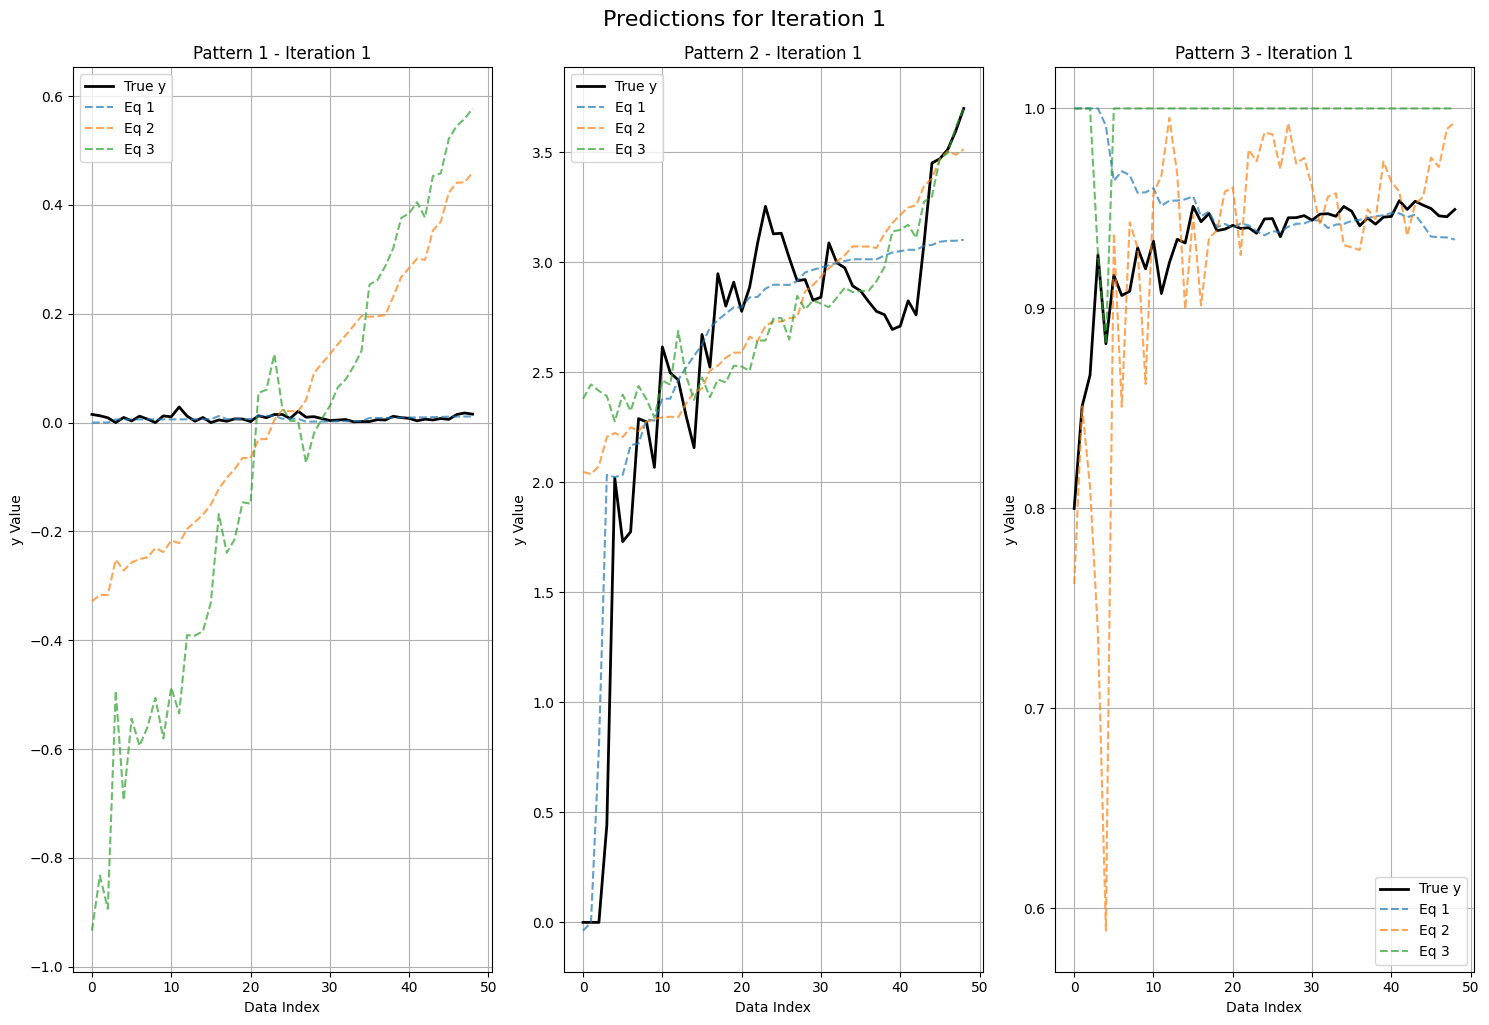

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*log(x1+1)+x2/(x3+1)', 'complexity': 12, 'nmae': np.float64(7.055553546939152), 'fitted_params': [-0.6286279603835232]}, {'equation': 'c[0]*x1*x2**2+c[1]*x4', 'complexity': 11, 'nmae': np.float64(0.17343976736903824), 'fitted_params': [0.00011525243046429023, 0.005645728746048401]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.1517219721653739), 'fitted_params': [0.010833346289359922, -9.048630479008395e-05]}, {'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x3', 'complexity': 16, 'nmae': np.float64(0.14852085152701014), 'fitted_params': [-0.010172010545313373, -0.0022067149735012963, 0.0027526111975209417]}], [{'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x3', 'complexity': 16, 'nmae': np.float64(0.10749121828619967), 'fitted_params': [0.02367322708412911, 1.0674896304815138, 13.007879008046885]}, {'equation': 'c[0]*x1+c[1]*x2/(x3+1)', 'complexity': 11, 'nmae': np.float64(0.10177381637059944

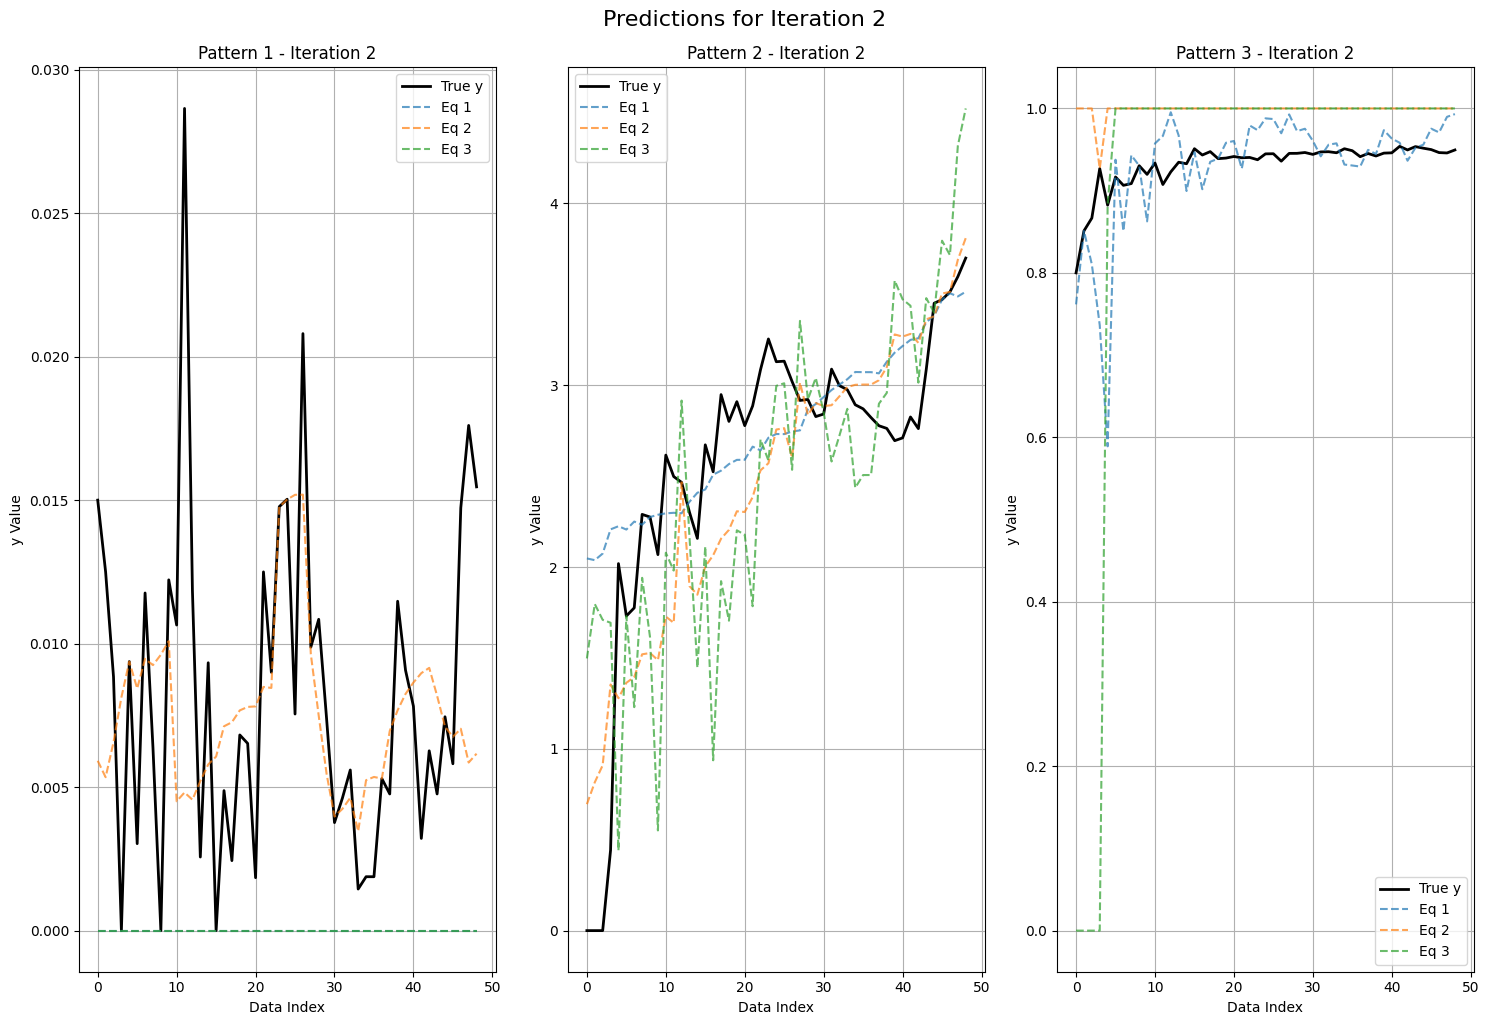

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*log(x1+1)+x2/(x3+1)', 'complexity': 12, 'nmae': np.float64(7.055553546939152), 'fitted_params': [-0.6286279603835232]}, {'equation': 'c[0]*x1*x2**2+c[1]*x4', 'complexity': 11, 'nmae': np.float64(0.17343976736903824), 'fitted_params': [0.00011525243046429023, 0.005645728746048401]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.1517219721653739), 'fitted_params': [0.010833346289359922, -9.048630479008395e-05]}, {'equation': 'c[0]*x1**3+c[1]*x2*x3+c[2]*log(x5+1)', 'complexity': 18, 'nmae': np.float64(0.14043025259530062), 'fitted_params': [0.008577021816867324, 0.0003073709031687721, -0.008175062502464369]}, {'equation': 'c[0]*sqrt(x1)+c[1]*x2/(x5+1)+c[2]*movavg(6, 3)', 'complexity': 16, 'nmae': np.float64(0.12845590235123697), 'fitted_params': [0.001811704245317628, 0.0036967788970810773, 0.006283009813818606]}], [{'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x3', 'complexity': 16, 'nmae':

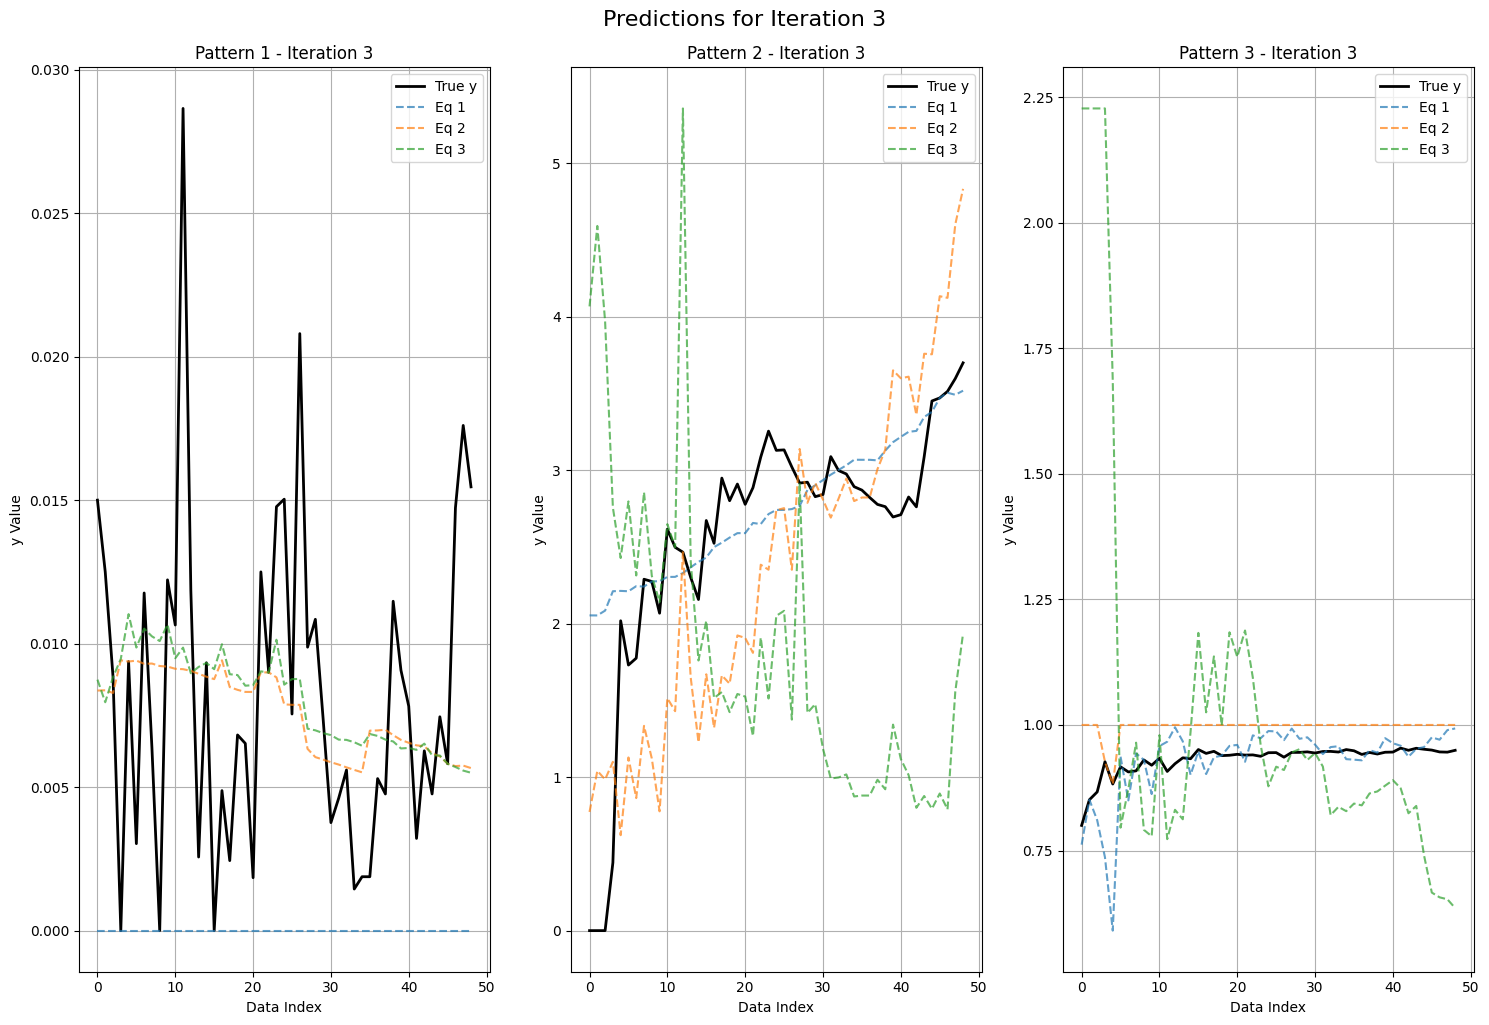

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*log(x1+1)+x2/(x3+1)', 'complexity': 12, 'nmae': np.float64(7.055553546939152), 'fitted_params': [-0.6286279603835232]}, {'equation': 'c[0]*x1*x2**2+c[1]*x4', 'complexity': 11, 'nmae': np.float64(0.17343976736903824), 'fitted_params': [0.00011525243046429023, 0.005645728746048401]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.1517219721653739), 'fitted_params': [0.010833346289359922, -9.048630479008395e-05]}, {'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x4/(x5+1)', 'complexity': 20, 'nmae': np.float64(0.1508779872927637), 'fitted_params': [0.014463148201342252, -0.0036185498446760465, 0.0013752424123720203]}, {'equation': 'c[0]*x1**3+c[1]*x2*x3+c[2]*log(x5+1)', 'complexity': 18, 'nmae': np.float64(0.14043025259530062), 'fitted_params': [0.008577021816867324, 0.0003073709031687721, -0.008175062502464369]}, {'equation': 'c[0]*sqrt(x1)+c[1]*x2/(x5+1)+c[2]*movavg(6, 3)', 'complexity': 16, '

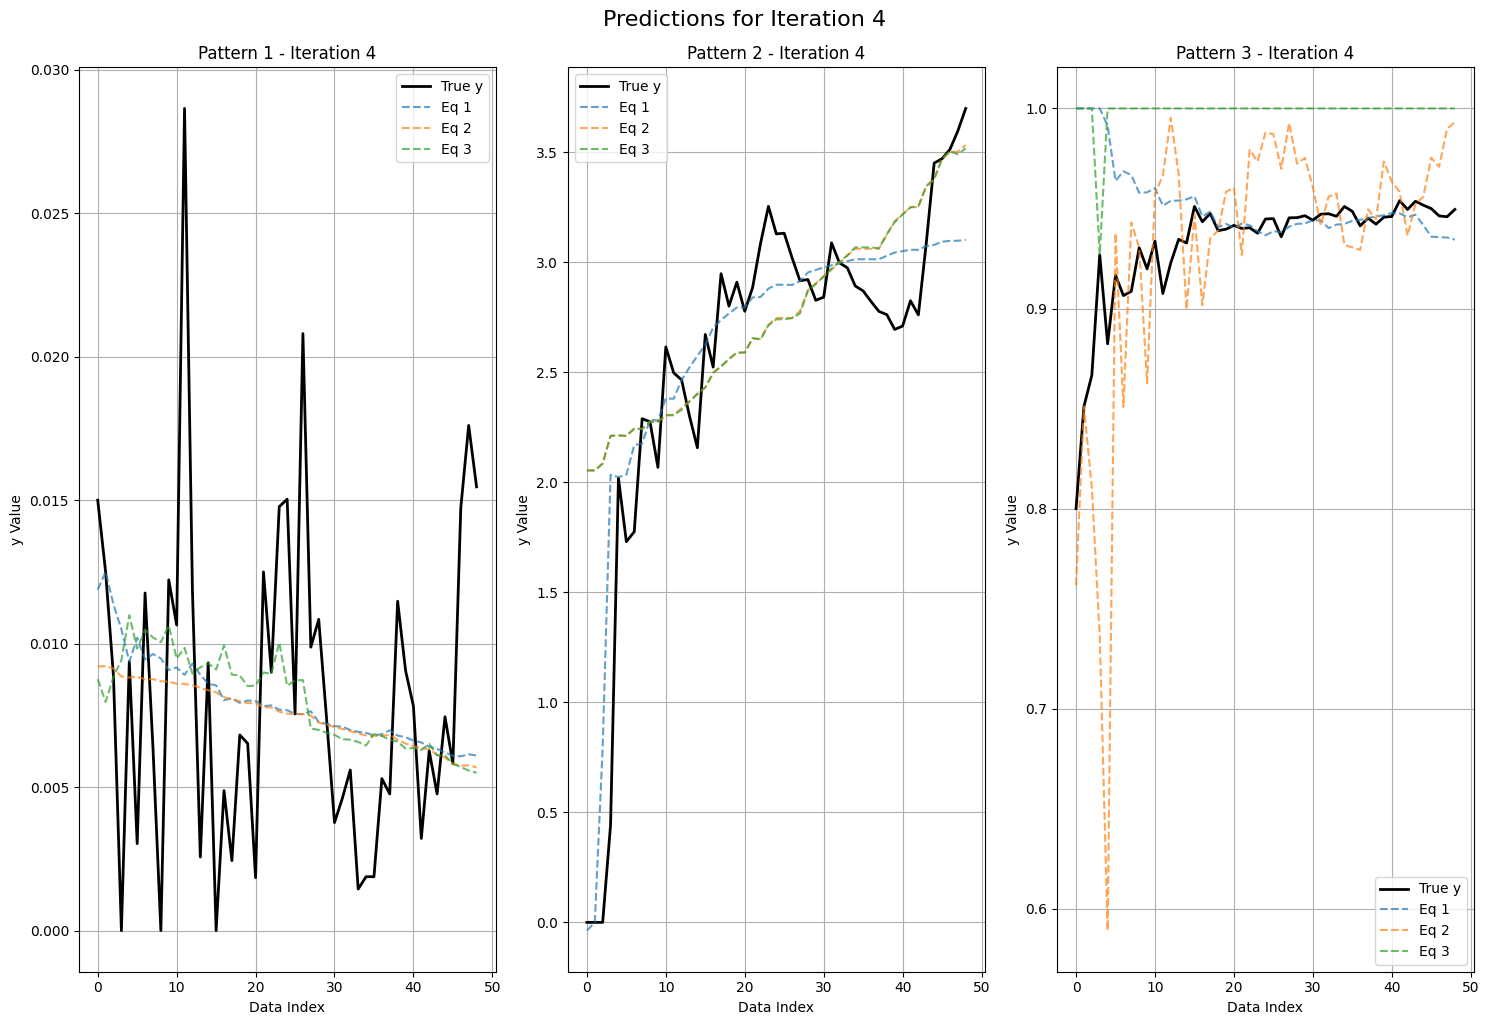

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.1517219721653739), 'fitted_params': [0.010833346289359922, -9.048630479008395e-05]}, {'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x4/(x5+1)', 'complexity': 20, 'nmae': np.float64(0.15087796256907224), 'fitted_params': [0.014486850428293938, -0.003624954317469835, 0.0013215741143721034]}, {'equation': 'c[0]*x1*x2+c[1]/(x3+1)', 'complexity': 11, 'nmae': np.float64(0.1507253870662417), 'fitted_params': [-0.0005460974110588633, 0.0770450177042186]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2)+c[2]*x3', 'complexity': 12, 'nmae': np.float64(0.14866694211453224), 'fitted_params': [-0.01869811585572949, -0.0018127317767583364, 0.003982523958591453]}, {'equation': 'c[0]*x1**3+c[1]*x2*x3+c[2]*log(x5+1)', 'complexity': 18, 'nmae': np.float64(0.14043025259530062), 'fitted_params': [0.008577021816867324, 0.0003073709031687721, -0.008175062502464369]}, {'equation': 'c[0]*sqrt(x1)+c[

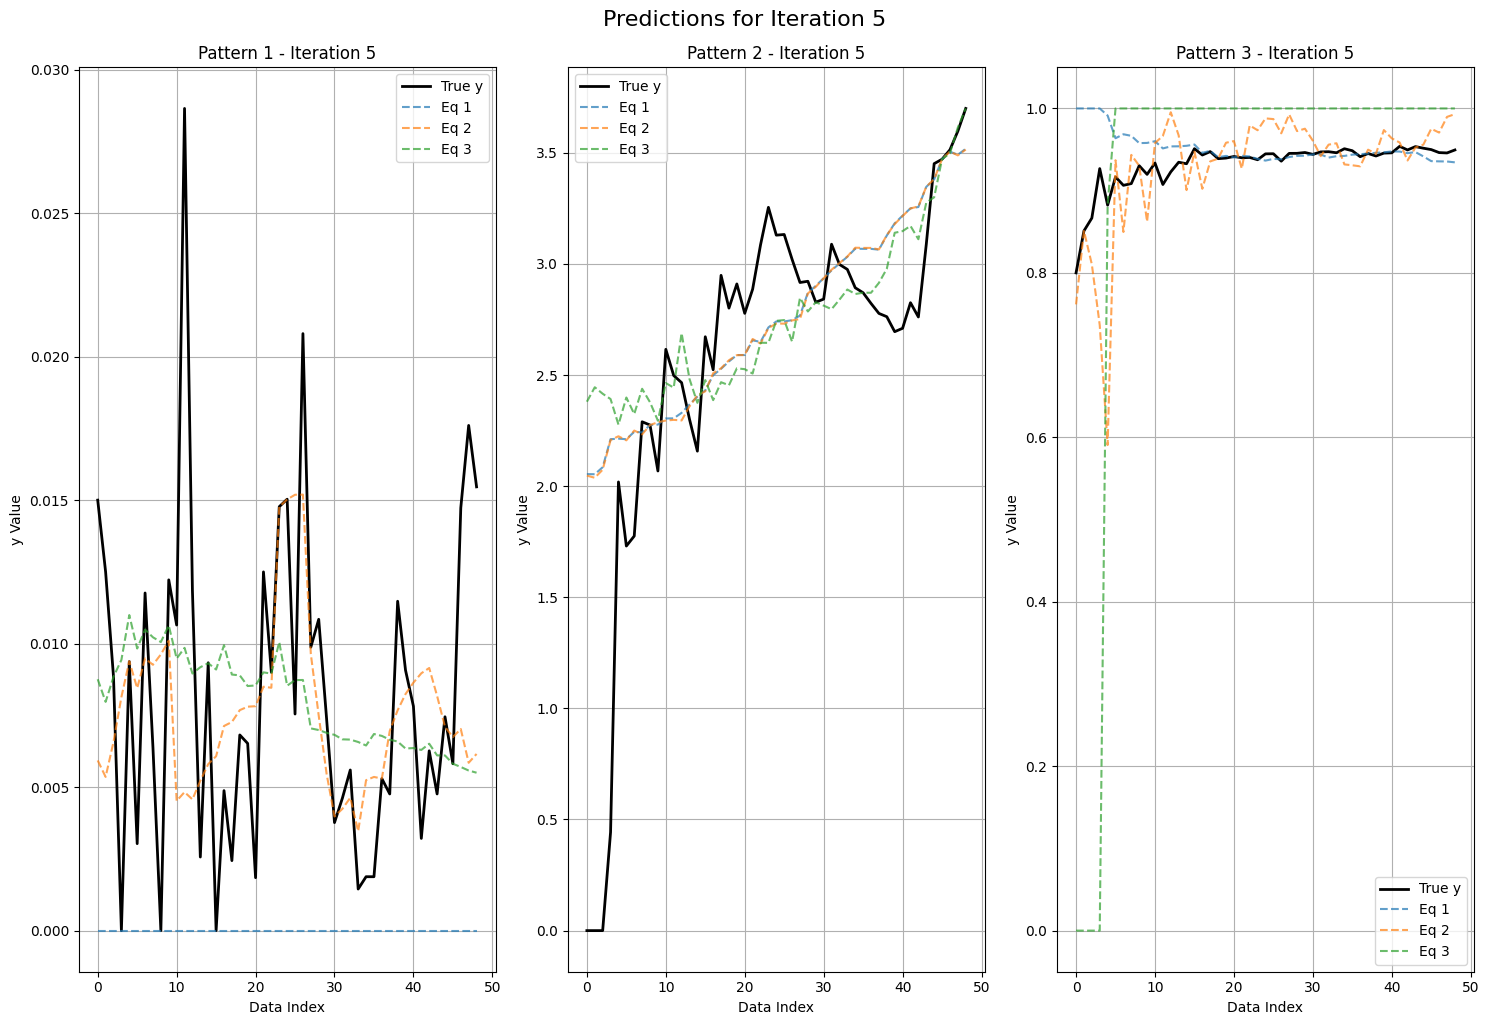

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.1517219721653739), 'fitted_params': [0.010833346289359922, -9.048630479008395e-05]}, {'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x4/(x5+1)', 'complexity': 20, 'nmae': np.float64(0.15087790729894549), 'fitted_params': [0.014486297683597264, -0.0036248280043250855, 0.0013281014643479966]}, {'equation': 'c[0]*x1*x2+c[1]/(x3+1)', 'complexity': 11, 'nmae': np.float64(0.1507253870662417), 'fitted_params': [-0.0005460974110588633, 0.0770450177042186]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2)+c[2]*x3', 'complexity': 12, 'nmae': np.float64(0.14866694211453224), 'fitted_params': [-0.01869811585572949, -0.0018127317767583364, 0.003982523958591453]}, {'equation': 'c[0]*x1**3+c[1]*x2*x3+c[2]*log(x5+1)', 'complexity': 18, 'nmae': np.float64(0.1404287031785277), 'fitted_params': [0.008600917976290999, 0.0003066801341134375, -0.008172027482343922]}, {'equation': 'c[0]*sqrt(x1)+c[

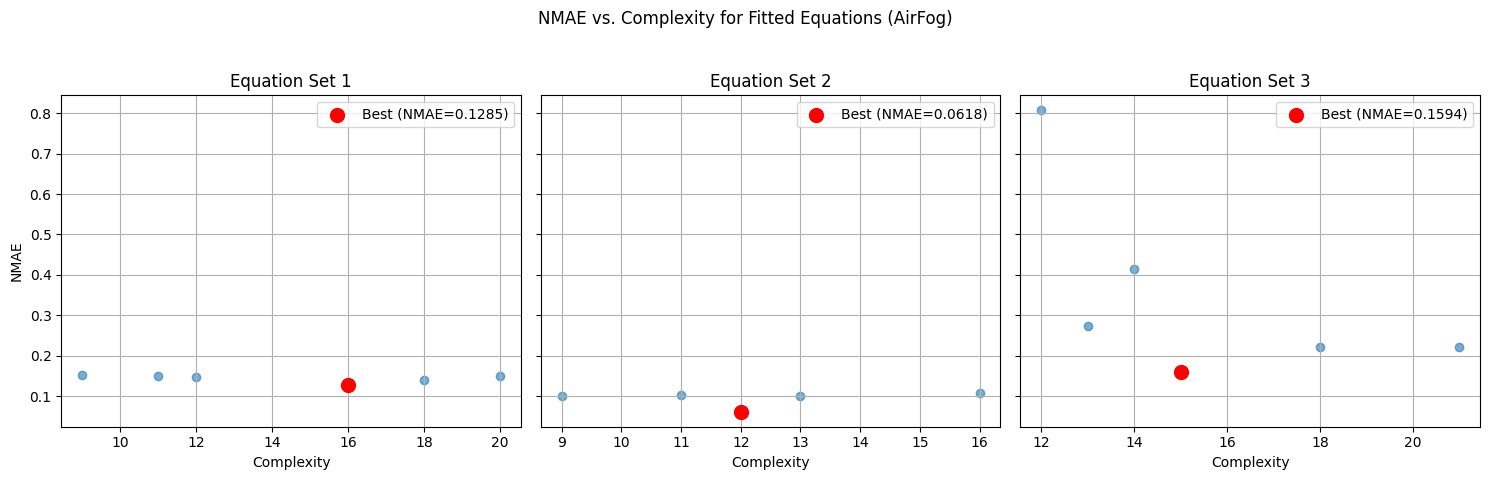

Experiment 3 finished.


In [6]:
import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "results/train"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")